Starting training...


 30%|███       | 15/50 [00:00<00:00, 35.73it/s]


Epoch [10/50] D_loss: 0.1279, G_loss: 0.4831


 54%|█████▍    | 27/50 [00:00<00:00, 37.34it/s]


Epoch [20/50] D_loss: 0.1002, G_loss: 0.5518


...


Epoch [30/50] D_loss: 0.0976, G_loss: 0.6077


 96%|█████████▌| 48/50 [00:01<00:00, 38.04it/s]


Epoch [40/50] D_loss: 0.0791, G_loss: 0.6060


100%|██████████| 50/50 [00:01<00:00, 36.25it/s]



Epoch [50/50] D_loss: 0.0665, G_loss: 0.6234


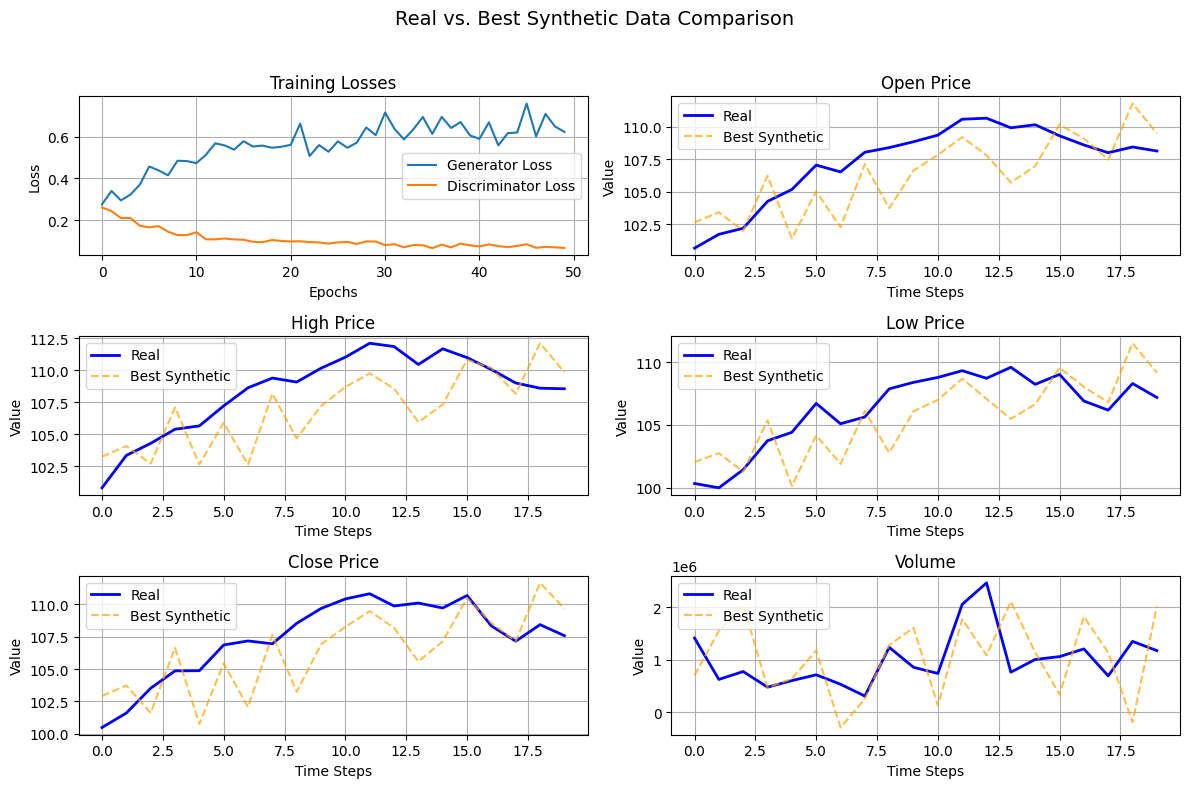

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def create_realistic_data(n_days=100):
    """Create realistic OHLCV financial data"""
    t = np.linspace(0, 4 * np.pi, n_days)
    base = 100 + t * 0.1 + np.sin(t) * 10
    
    data = np.zeros((n_days, 5))
    for i in range(n_days):
        daily_vol = np.abs(np.random.normal(0, 0.01))
        open_price = base[i] * (1 + np.random.normal(0, 0.005))
        close_price = base[i] * (1 + np.random.normal(0, 0.005))
        high_price = max(open_price, close_price) * (1 + daily_vol)
        low_price = min(open_price, close_price) * (1 - daily_vol)
        volume = np.random.lognormal(mean=np.log(1000000), sigma=0.5)
        
        data[i] = [open_price, high_price, low_price, close_price, volume]
    
    return data

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=20):
        self.orig_data = data.copy()
        self.seq_len = seq_len
        
        # Calculate statistics for OHLC
        self.price_mean = np.mean(data[:, :4])
        self.price_std = np.std(data[:, :4])
        
        # Calculate statistics for volume
        self.vol_mean = np.mean(data[:, 4])
        self.vol_std = np.std(data[:, 4])
        
        # Normalize data
        norm_data = np.zeros_like(data)
        norm_data[:, :4] = (data[:, :4] - self.price_mean) / self.price_std
        norm_data[:, 4] = (data[:, 4] - self.vol_mean) / self.vol_std
        
        # Create sequences
        self.sequences = []
        for i in range(len(norm_data) - seq_len):
            self.sequences.append(norm_data[i:i+seq_len])
        self.sequences = np.array(self.sequences)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])
    
    def denormalize(self, data):
        data = data.detach().cpu().numpy() if torch.is_tensor(data) else data
        result = np.zeros_like(data)
        result[:, :, :4] = data[:, :, :4] * self.price_std + self.price_mean
        result[:, :, 4] = data[:, :, 4] * self.vol_std + self.vol_mean
        return result

class Discriminator(nn.Module):
    def __init__(self, seq_len=20):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * 5, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

class Generator(nn.Module):
    def __init__(self, seq_len=20, latent_dim=32):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        
        # Shared base - keep it simple
        self.shared = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
        )
        
        # Separate heads for trend and noise
        self.trend = nn.Linear(128, seq_len)
        self.noise = nn.Linear(128, seq_len)
        
        # Separate volume network (no shared features)
        self.volume = nn.Sequential(
            nn.Linear(latent_dim, 128),  # Takes raw z input
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, seq_len),
            nn.Tanh()
        )
    
    def forward(self, z):
        batch_size = z.size(0)
        h = self.shared(z)
        
        # Generate trend component
        trend = torch.cumsum(self.trend(h), dim=1).unsqueeze(-1)
        noise = 0.1 * self.noise(h).unsqueeze(-1)
        
        # Base price combining trend and noise
        base_price = trend + noise
        
        # Generate OHLC from base price
        open_price = base_price
        high_price = base_price + torch.abs(noise)
        low_price = base_price - torch.abs(noise)
        close_price = base_price + 0.5 * noise
        
        # Volume - using the separate network
        volume = self.volume(z).unsqueeze(-1) * 5  # Use raw z, not shared h
        
        return torch.cat([
            open_price,
            high_price,
            low_price,
            close_price,
            volume
        ], dim=2)

def train_financial_gan(generator, discriminator, train_data, config):
    print("Starting training...")
    
    default_config = {
        'n_epochs': 50,
        'batch_size': 16,
        'lr': 0.0001,
        'beta1': 0.5,
        'beta2': 0.999
    }
    config = {**default_config, **config}
    
    dataset = FinancialDataset(train_data, seq_len=20)
    dataloader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
    
    g_optimizer = optim.Adam(generator.parameters(), lr=config['lr'], 
                           betas=(config['beta1'], config['beta2']))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=config['lr'],
                           betas=(config['beta1'], config['beta2']))
    
    def price_consistency_loss(data):
        """Focus on trend consistency and reduced volatility"""
        prices = data[:, :, :4]
        
        # Price relationships
        highs = prices[:, :, 1]
        lows = prices[:, :, 2]
        relationship_loss = torch.relu(lows - highs).mean()
        
        # Trend consistency
        price_changes = torch.diff(prices[:, :, 3], dim=1)  # Use close prices
        trend_changes = torch.diff(price_changes, dim=1)
        trend_loss = torch.abs(trend_changes).mean()  # Penalize trend changes
        
        # Volatility control
        volatility_loss = torch.abs(price_changes).mean()
        
        return relationship_loss + 0.1 * trend_loss + 0.05 * volatility_loss
    
    g_losses, d_losses = [], []
    
    for epoch in tqdm(range(config['n_epochs'])):
        epoch_g_losses = []
        epoch_d_losses = []
        
        for real_batch in dataloader:
            batch_size = real_batch.size(0)
            
            # Train Discriminator
            d_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z).detach()
            
            d_real = discriminator(real_batch)
            d_fake = discriminator(fake_data)
            
            # Simple MSE loss for stability
            d_loss = (torch.mean((d_real - 1)**2) + torch.mean(d_fake**2)) / 2
            
            d_loss.backward()
            d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z)
            g_fake = discriminator(fake_data)
            
            # Generator losses
            g_loss = torch.mean((g_fake - 1)**2)
            consistency = price_consistency_loss(fake_data)
            
            total_g_loss = g_loss + consistency
            
            total_g_loss.backward()
            g_optimizer.step()
            
            epoch_g_losses.append(g_loss.item())
            epoch_d_losses.append(d_loss.item())
        
        g_losses.append(np.mean(epoch_g_losses))
        d_losses.append(np.mean(epoch_d_losses))
        
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch [{epoch+1}/{config['n_epochs']}] "
                  f"D_loss: {d_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}")
    
    return generator, discriminator, {'g_losses': g_losses, 'd_losses': d_losses}

def plot_comparison(real_data, synthetic_data, history, window=20):
    # plt.style.use('seaborn')
    
    # First figure: OHLC plots
    fig1 = plt.figure(figsize=(20, 12))
    
    # 1. Plot losses
    plt.subplot(2, 2, 1)
    plt.plot(history['g_losses'], label='Generator')
    plt.plot(history['d_losses'], label='Discriminator')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)
    
    # 2. Plot OHLC
    def plot_sequence(ax, real_seq, synth_seqs, idx, title):
        ax.plot(real_seq[:window, idx], label='Real', color='blue', linewidth=2)
        for i, syn_data in enumerate(synth_seqs[:3]):
            ax.plot(syn_data[:window, idx], 
                   label=f'Synthetic {i+1}', 
                   alpha=0.6,
                   linestyle='--')
        ax.set_title(title)
        ax.legend()
        ax.grid(True)
    
    # Plot Open prices
    plt.subplot(2, 2, 2)
    plot_sequence(plt.gca(), real_data, synthetic_data, 0, 'Real vs Synthetic Open Prices')
    
    # Plot High-Low prices
    plt.subplot(2, 2, 3)
    plt.plot(real_data[:window, 1], label='Real High', color='blue', linestyle='--')
    plt.plot(real_data[:window, 2], label='Real Low', color='blue', linestyle=':')
    for i in range(min(3, len(synthetic_data))):
        plt.plot(synthetic_data[i, :window, 1], 
                label=f'Synthetic High {i+1}',
                alpha=0.6,
                linestyle='--')
        plt.plot(synthetic_data[i, :window, 2], 
                label=f'Synthetic Low {i+1}',
                alpha=0.6,
                linestyle=':')
    plt.title('Real vs Synthetic High-Low Prices')
    plt.legend()
    plt.grid(True)
    
    # Plot Close prices
    plt.subplot(2, 2, 4)
    plot_sequence(plt.gca(), real_data, synthetic_data, 3, 'Real vs Synthetic Close Prices')
    
    plt.tight_layout()
    plt.show()
    
    # Second figure: Volume plots
    fig2 = plt.figure(figsize=(15, 6))
    
    # Volume time series
    plt.subplot(1, 2, 1)
    plt.plot(real_data[:window, 4], label='Real Volume', color='blue', linewidth=2)
    for i in range(min(3, len(synthetic_data))):
        plt.plot(synthetic_data[i, :window, 4], 
                label=f'Synthetic Volume {i+1}',
                alpha=0.6,
                linestyle='--')
    plt.title('Real vs Synthetic Volume')
    plt.legend()
    plt.grid(True)
    
    # Volume distribution
    plt.subplot(1, 2, 2)
    plt.hist(real_data[:, 4], bins=30, alpha=0.5, label='Real Volume', 
            density=True, color='blue')
    plt.hist(synthetic_data[:, :, 4].flatten(), bins=30, alpha=0.5,
            label='Synthetic Volume', density=True, color='orange')
    plt.title('Volume Distribution')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def select_best_synthetic_sequence(real_seq, synthetic_seqs):
    """
    Selects the best synthetic sequence based on Mean Squared Error with the real data.
    real_seq and synth_seq are truncated to match the window length.
    """
    # Ensure real_seq and each synthetic sequence have the same length for comparison
    real_seq_truncated = real_seq[:len(synthetic_seqs[0])]
    errors = [np.mean((real_seq_truncated - synth_seq) ** 2) for synth_seq in synthetic_seqs]
    best_index = np.argmin(errors)
    return synthetic_seqs[best_index]

def plot_comparison(real_data, synthetic_data, history, window=20):
    # Select the best synthetic sequences for each feature against the real data
    best_synthetic_data = [select_best_synthetic_sequence(real_data[:window, i], synthetic_data[:, :window, i]) for i in range(5)]
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    fig.suptitle("Real vs. Best Synthetic Data Comparison", fontsize=14)
    axes = axes.flatten()

    # 1. Plot Training Losses
    axes[0].plot(history['g_losses'], label='Generator Loss')
    axes[0].plot(history['d_losses'], label='Discriminator Loss')
    axes[0].set_title('Training Losses')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Helper function to plot real vs best synthetic for specific price features
    def plot_feature_comparison(ax, real_seq, best_synth_seq, title):
        ax.plot(real_seq[:window], label='Real', color='blue', linewidth=2)
        ax.plot(best_synth_seq[:window], label='Best Synthetic', linestyle='--', color='orange', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True)

    # 2. Open Price
    plot_feature_comparison(axes[1], real_data[:, 0], best_synthetic_data[0], 'Open Price')

    # 3. High Price
    plot_feature_comparison(axes[2], real_data[:, 1], best_synthetic_data[1], 'High Price')

    # 4. Low Price
    plot_feature_comparison(axes[3], real_data[:, 2], best_synthetic_data[2], 'Low Price')

    # 5. Close Price
    plot_feature_comparison(axes[4], real_data[:, 3], best_synthetic_data[3], 'Close Price')

    # 6. Volume
    plot_feature_comparison(axes[5], real_data[:, 4], best_synthetic_data[4], 'Volume')

    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
    plt.show()



def main():
    # Generate data
    real_data = create_realistic_data(n_days=100)
    
    # Initialize models
    generator = Generator(seq_len=20, latent_dim=32)
    discriminator = Discriminator(seq_len=20)
    
    # Training configuration
    config = {
        'n_epochs': 50,
        'batch_size': 16,
        'lr': 0.0001
    }
    
    # Train
    generator, discriminator, history = train_financial_gan(
        generator,
        discriminator,
        real_data,
        config
    )
    
    # Generate synthetic data
    with torch.no_grad():
        z = torch.randn(10, generator.latent_dim)
        synthetic_data = generator(z)
        dataset = FinancialDataset(real_data, seq_len=20)
        synthetic_data = dataset.denormalize(synthetic_data)
    
    # Plot results
    plot_comparison(real_data, synthetic_data, history)

if __name__ == "__main__":
    main()

## Multiple tickers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Parameters
tickers = ['AAPL', 'GOOG', 'MSFT']
features = ['open', 'close', 'low', 'high', 'volume']
start_date = '2020-01-01'
end_date = '2020-12-31'

# Function to load data
def load_data(tickers, start_date, end_date):
    data_frames = []
    for ticker in tickers:
        df = yf.download(ticker, start=start_date, end=end_date)
        df.reset_index(inplace=True)
        df['ticker'] = ticker
        df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
        df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
        data_frames.append(df)
    return pd.concat(data_frames).reset_index(drop=True)

# Load the data
data = load_data(tickers, start_date, end_date)
data



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,date,open,close,low,high,volume,ticker
0,2020-01-02,74.059998,75.087502,73.797501,75.150002,135480400,AAPL
1,2020-01-03,74.287498,74.357498,74.125000,75.144997,146322800,AAPL
2,2020-01-06,73.447502,74.949997,73.187500,74.989998,118387200,AAPL
3,2020-01-07,74.959999,74.597504,74.370003,75.224998,108872000,AAPL
4,2020-01-08,74.290001,75.797501,74.290001,76.110001,132079200,AAPL
...,...,...,...,...,...,...,...
751,2020-12-23,223.110001,221.020004,220.800003,223.559998,18699600,MSFT
752,2020-12-24,221.419998,222.750000,221.199997,223.610001,10550600,MSFT
753,2020-12-28,224.449997,224.960007,223.020004,226.029999,17933500,MSFT
754,2020-12-29,226.309998,224.149994,223.580002,227.179993,17403200,MSFT


In [2]:
data.nunique()

date      252
open      742
close     747
low       745
high      736
volume    756
ticker      3
dtype: int64

In [3]:
# Convert date to ordinal
data['date'] = pd.to_datetime(data['date'])
data.sort_values(['date', 'ticker'], inplace=True)
data['date_ordinal'] = data['date'].apply(lambda x: x.toordinal())
data

,date,open,close,low,high,volume,ticker,date_ordinal
0,2020-01-02,74.059998,75.087502,73.797501,75.150002,135480400,AAPL,737426
252,2020-01-02,67.077499,68.368500,67.077499,68.406998,28132000,GOOG,737426
504,2020-01-02,158.779999,160.619995,158.330002,160.729996,22622100,MSFT,737426
1,2020-01-03,74.287498,74.357498,74.125000,75.144997,146322800,AAPL,737427
253,2020-01-03,67.392998,68.032997,67.277199,68.625000,23728000,GOOG,737427
...,...,...,...,...,...,...,...,...
502,2020-12-29,89.389503,87.935997,87.804497,89.622002,25988000,GOOG,737788
754,2020-12-29,226.309998,224.149994,223.580002,227.179993,17403200,MSFT,737788
251,2020-12-30,135.580002,133.720001,133.399994,135.990005,96452100,AAPL,737789
503,2020-12-30,88.100502,86.975998,86.279999,88.254753,26122000,GOOG,737789


/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


AAPL - Epoch 1, Loss: 0.3965
AAPL - Epoch 2, Loss: 0.0960
AAPL - Epoch 3, Loss: 0.0527
AAPL - Epoch 4, Loss: 0.0263
AAPL - Epoch 5, Loss: 0.0219
AAPL - Epoch 6, Loss: 0.0188
AAPL - Epoch 7, Loss: 0.0165
AAPL - Epoch 8, Loss: 0.0142
AAPL - Epoch 9, Loss: 0.0143
AAPL - Epoch 10, Loss: 0.0145


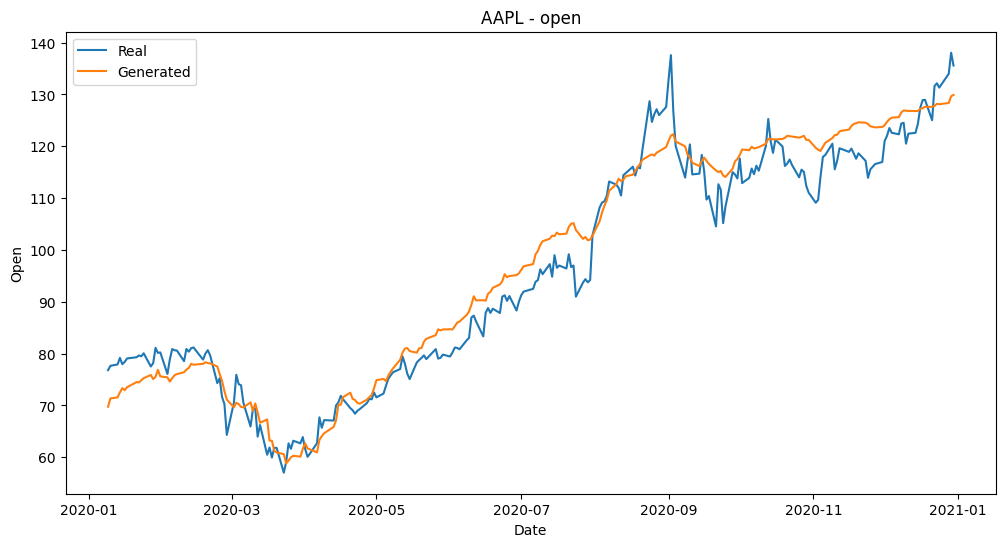

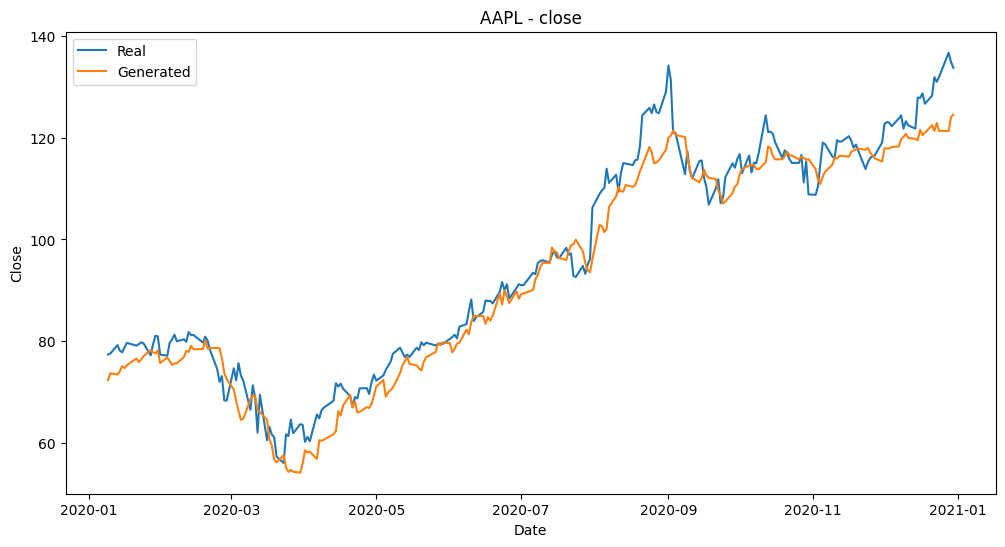

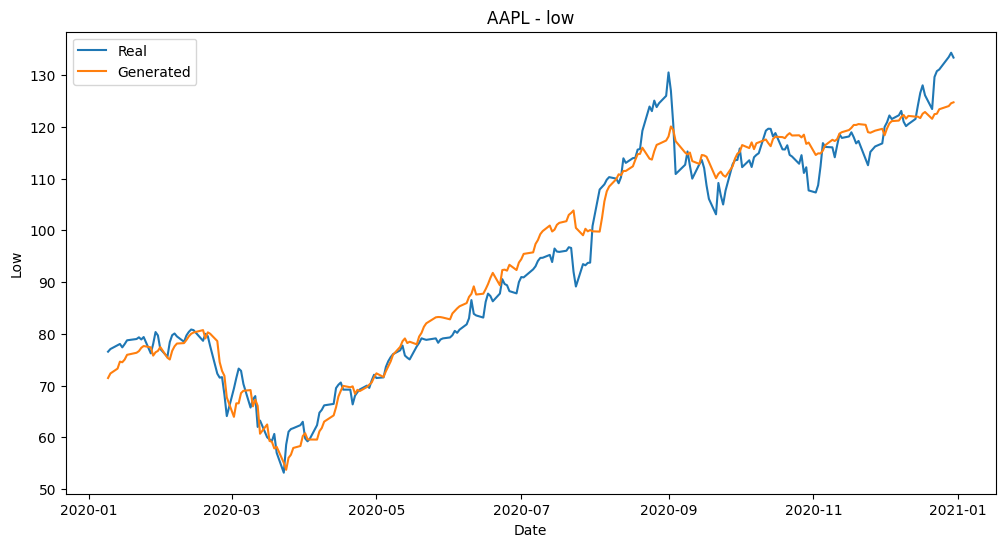

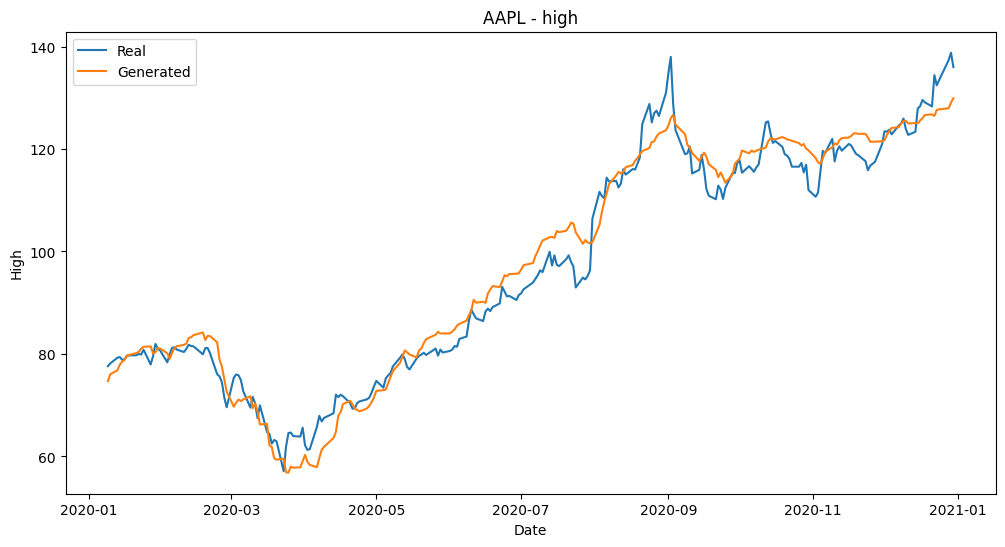

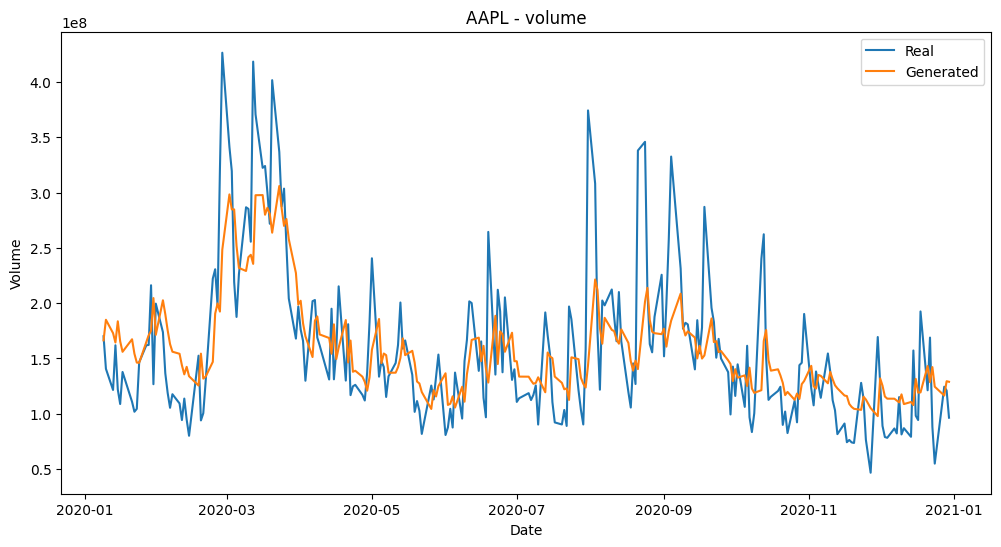

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


GOOG - Epoch 1, Loss: 0.0923
GOOG - Epoch 2, Loss: 0.0349
GOOG - Epoch 3, Loss: 0.0247
GOOG - Epoch 4, Loss: 0.0192
GOOG - Epoch 5, Loss: 0.0172
GOOG - Epoch 6, Loss: 0.0142
GOOG - Epoch 7, Loss: 0.0142
GOOG - Epoch 8, Loss: 0.0141
GOOG - Epoch 9, Loss: 0.0121
GOOG - Epoch 10, Loss: 0.0119


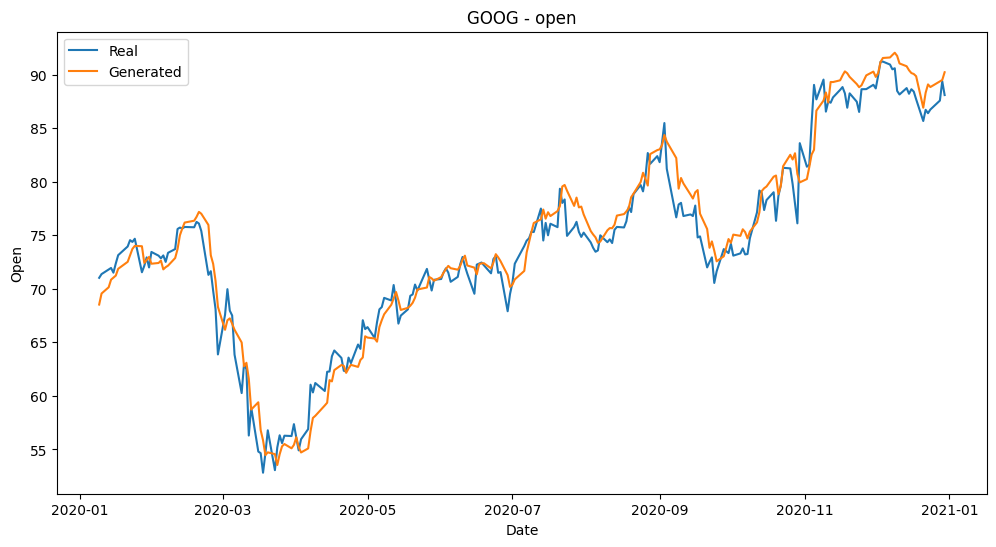

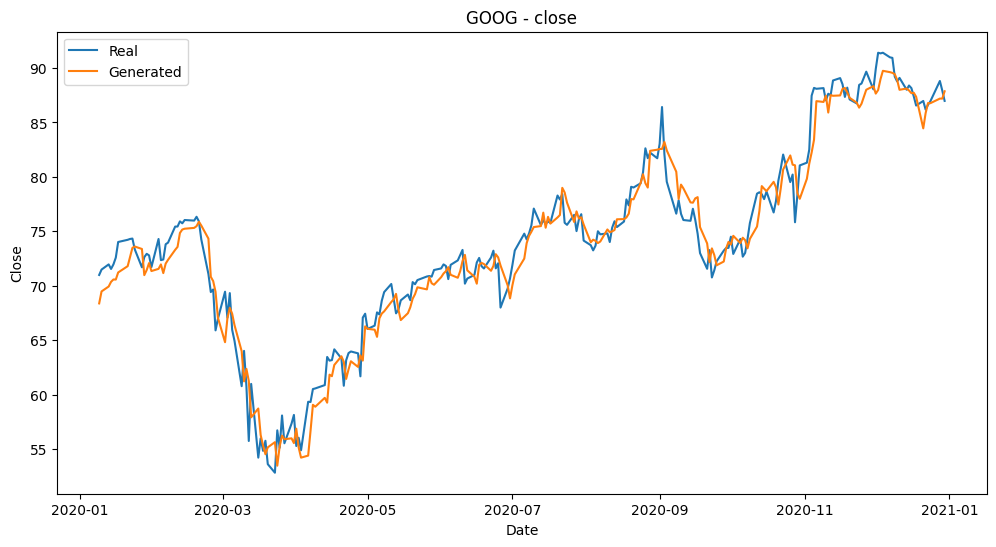

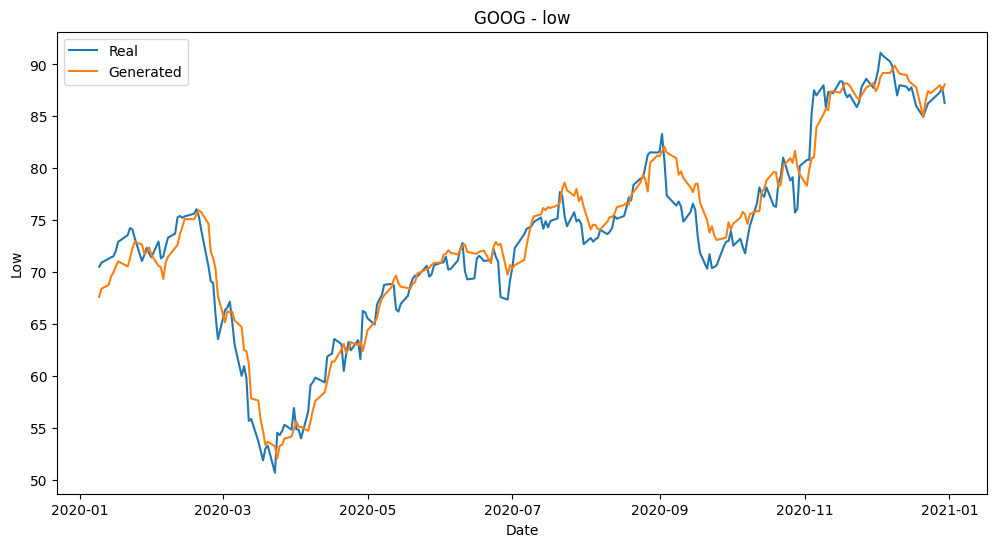

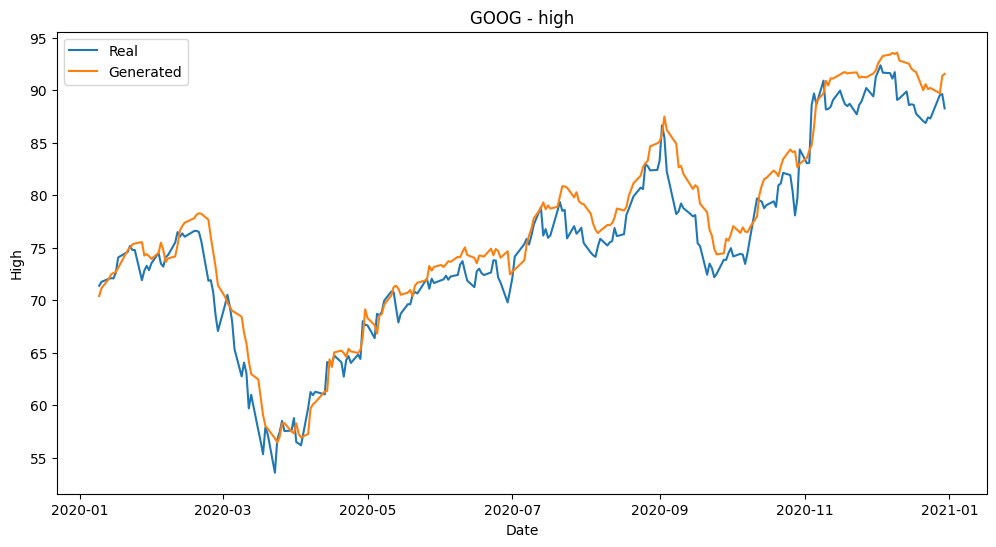

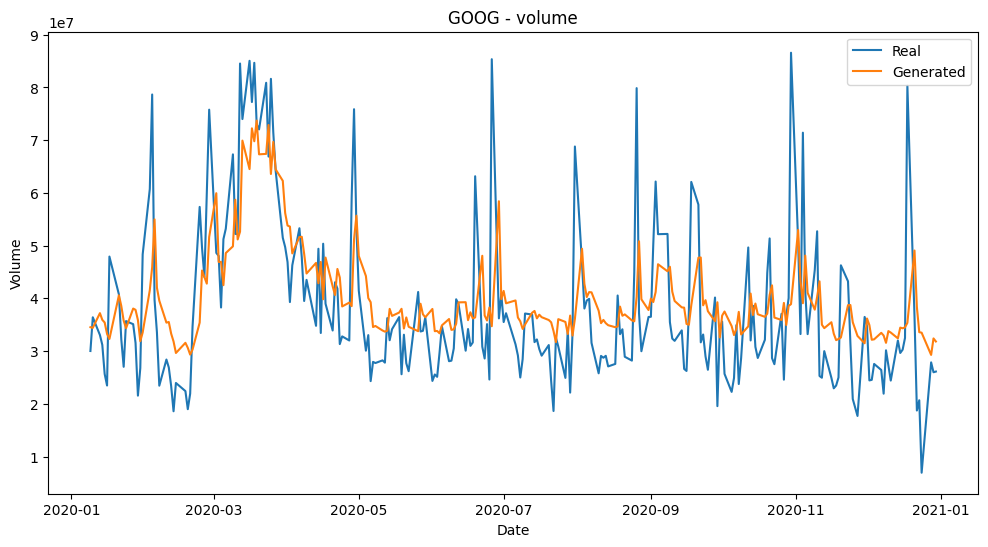

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


MSFT - Epoch 1, Loss: 0.1916
MSFT - Epoch 2, Loss: 0.0489
MSFT - Epoch 3, Loss: 0.0304
MSFT - Epoch 4, Loss: 0.0224
MSFT - Epoch 5, Loss: 0.0180
MSFT - Epoch 6, Loss: 0.0173
MSFT - Epoch 7, Loss: 0.0159
MSFT - Epoch 8, Loss: 0.0153
MSFT - Epoch 9, Loss: 0.0153
MSFT - Epoch 10, Loss: 0.0135


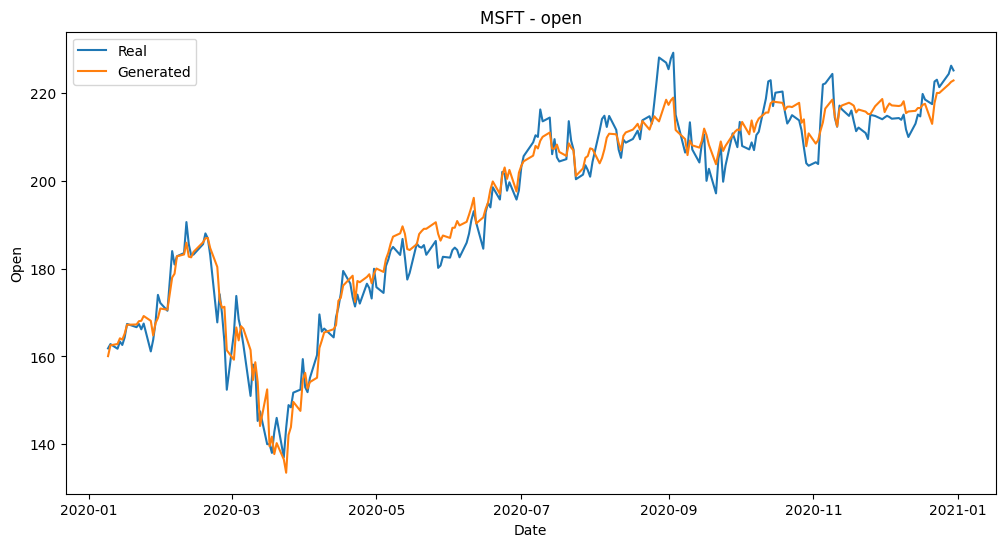

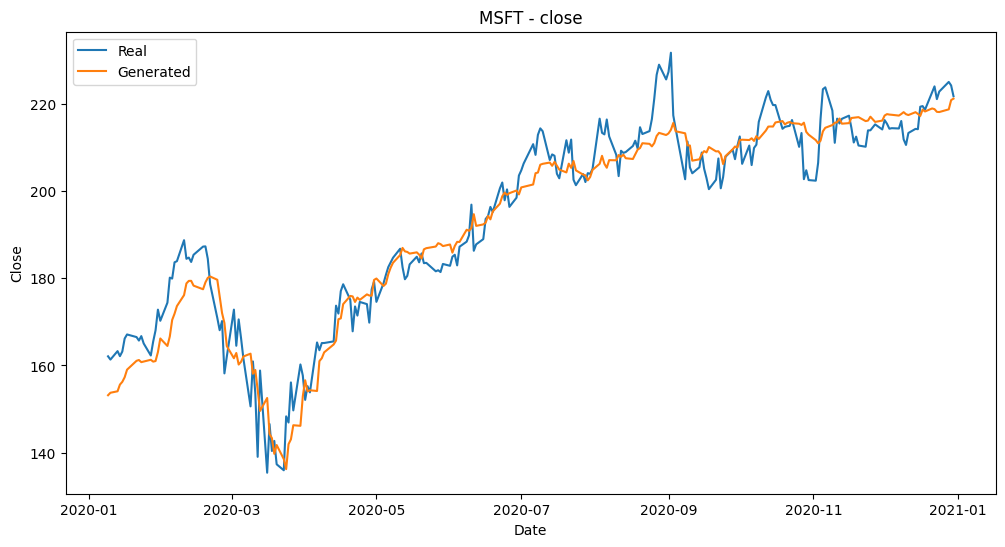

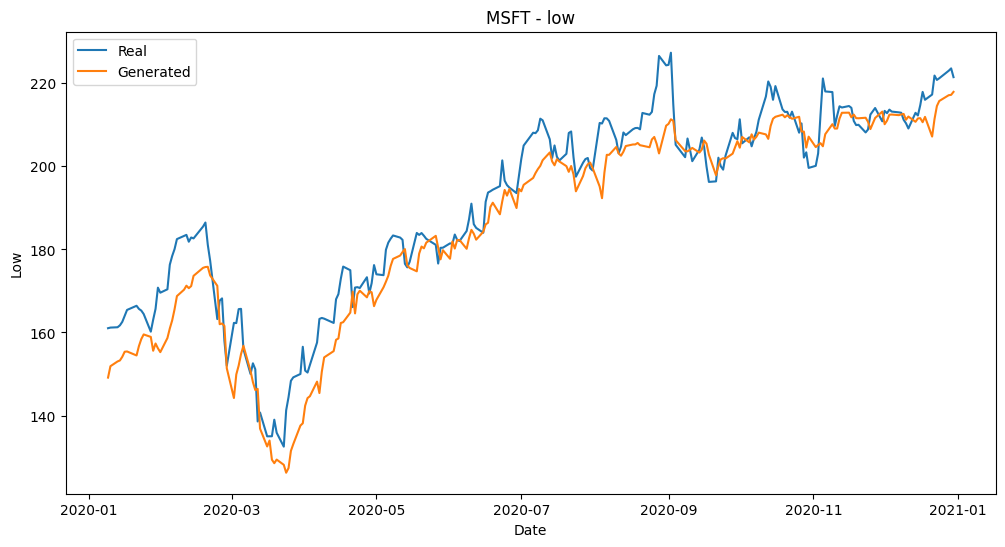

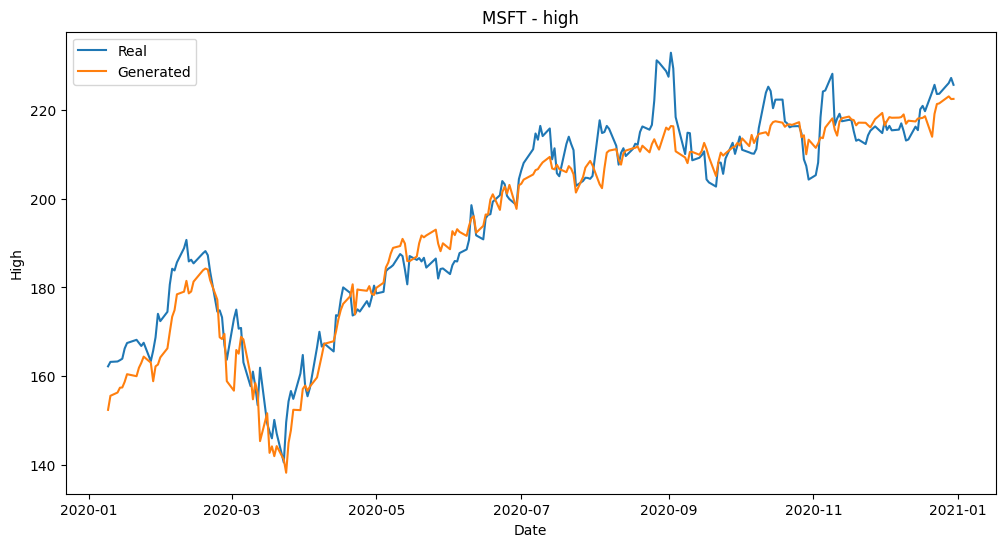

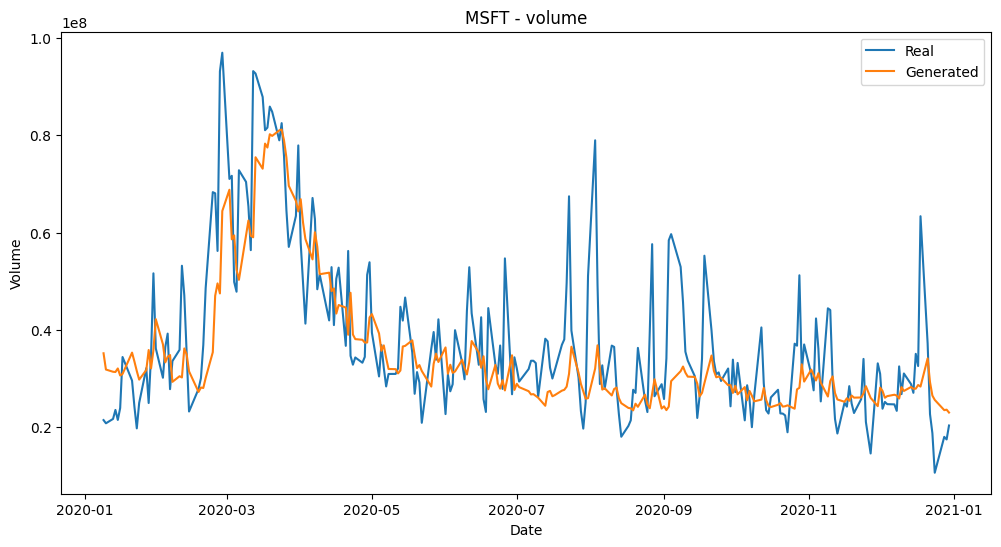

In [4]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, num_layers, d_model, nhead, dim_feedforward, output_size):
        super(TransformerModel, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src):
        # src shape: (batch_size, sequence_length, input_size)
        src = src.permute(1, 0, 2)  # (sequence_length, batch_size, input_size)
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[-1])  # Use the last time step
        return output

for ticker in tickers:
    # Get data for the ticker
    df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
    
    # Scaling
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    df_features = df_ticker[['date_ordinal', 'open', 'close', 'low', 'high', 'volume']]
    df_targets = df_ticker[features]
    
    feature_scaler.fit(df_features)
    target_scaler.fit(df_targets)
    
    scaled_features = feature_scaler.transform(df_features)
    scaled_targets = target_scaler.transform(df_targets)
    
    # Create sequences
    sequence_length = 5
    X = []
    y = []
    
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
        y.append(scaled_targets[i+sequence_length])  # Target is the next time step's features
    
    X = np.array(X)
    y = np.array(y)
    
    # Prepare PyTorch datasets
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
    
    # Define the model
    input_size = X.shape[2]
    output_size = y.shape[1]
    
    model = TransformerModel(
        input_size=input_size,
        num_layers=2,
        d_model=64,
        nhead=4,
        dim_feedforward=128,
        output_size=output_size
    )
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training
    epochs = 10
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"{ticker} - Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")
    
    # Generate predictions
    X_pred = []
    for i in range(len(scaled_features) - sequence_length):
        X_pred.append(scaled_features[i:i+sequence_length])
    
    X_pred = np.array(X_pred)
    X_pred_tensor = torch.tensor(X_pred, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_pred_tensor)
        y_pred = y_pred.numpy()
    
    # Inverse transform predictions and actual targets
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_true_inv = target_scaler.inverse_transform(y)
    
    # Prepare comparison DataFrame
    dates = df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)
    comparison_df = pd.DataFrame(y_true_inv, columns=features)
    comparison_df['date'] = dates
    comparison_df['ticker'] = ticker
    for i, feature in enumerate(features):
        comparison_df[feature + '_pred'] = y_pred_inv[:, i]
    
    # Plot comparisons per feature
    for feature in features:
        plt.figure(figsize=(12, 6))
        plt.plot(comparison_df['date'], comparison_df[feature], label='Real')
        plt.plot(comparison_df['date'], comparison_df[feature + '_pred'], label='Generated')
        plt.title(f"{ticker} - {feature}")
        plt.xlabel('Date')
        plt.ylabel(feature.capitalize())
        plt.legend()
        plt.show()


# Transformer + GAN

Loading data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Training AAPL...
Epoch 2, G Loss: 0.0829, D Loss: 0.6926
Epoch 4, G Loss: 0.0776, D Loss: 0.6915
Epoch 6, G Loss: 0.0753, D Loss: 0.6914
Epoch 8, G Loss: 0.0742, D Loss: 0.6905
Epoch 10, G Loss: 0.0735, D Loss: 0.6901


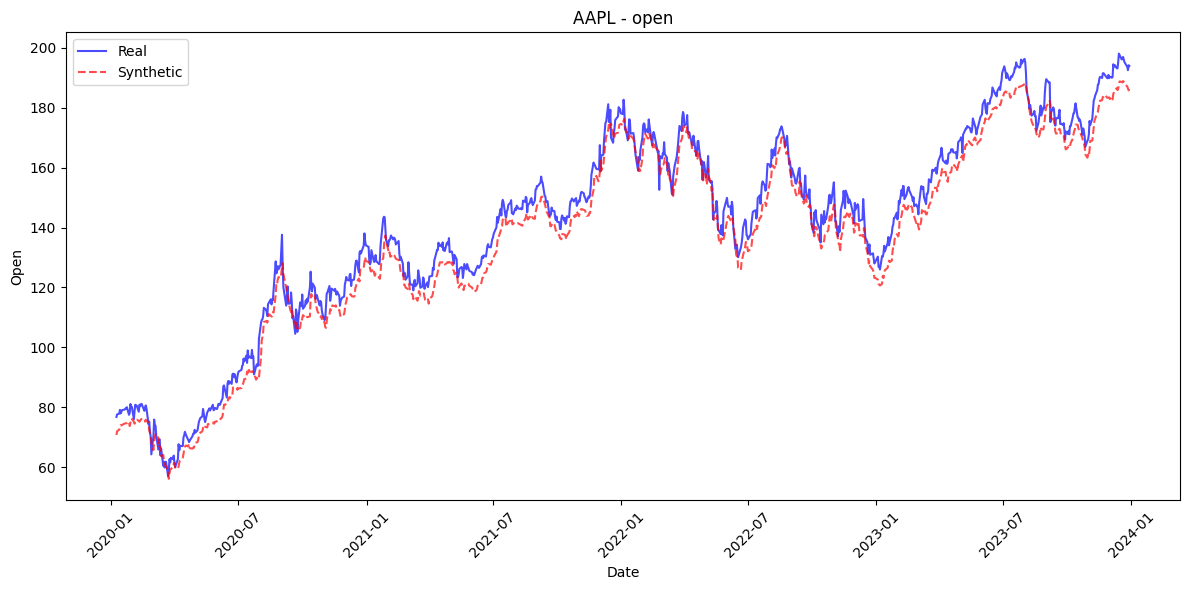

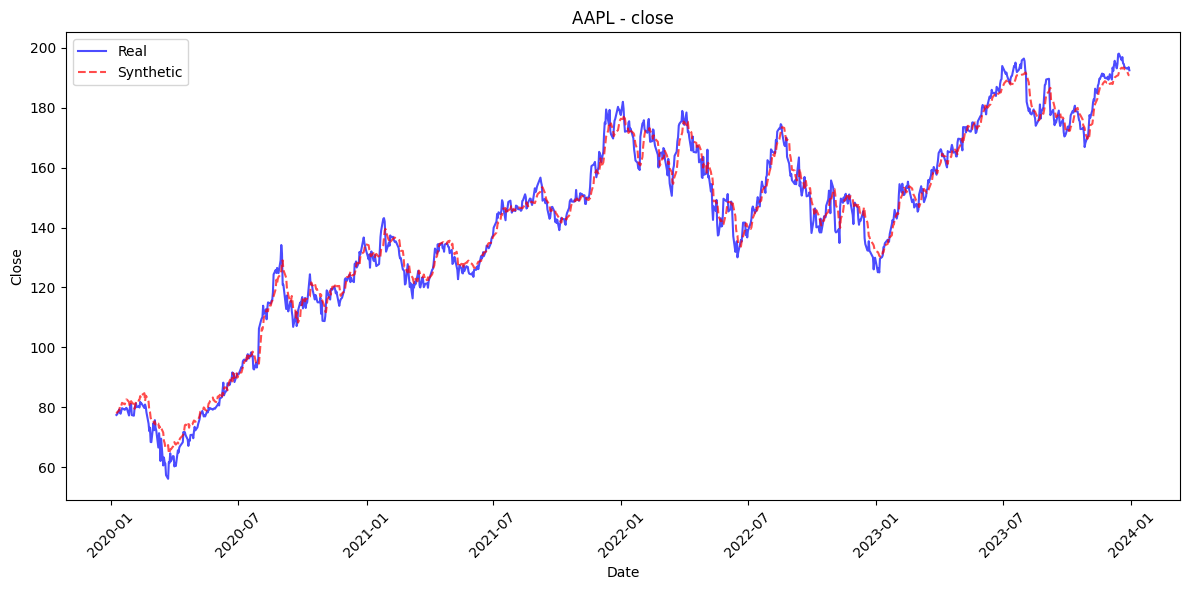

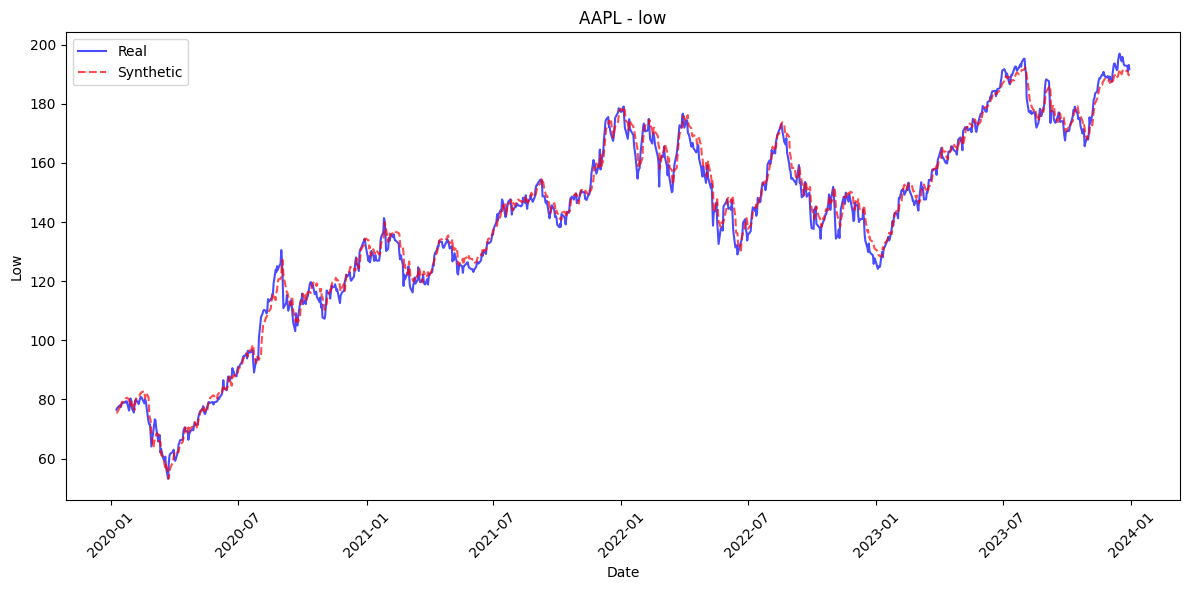

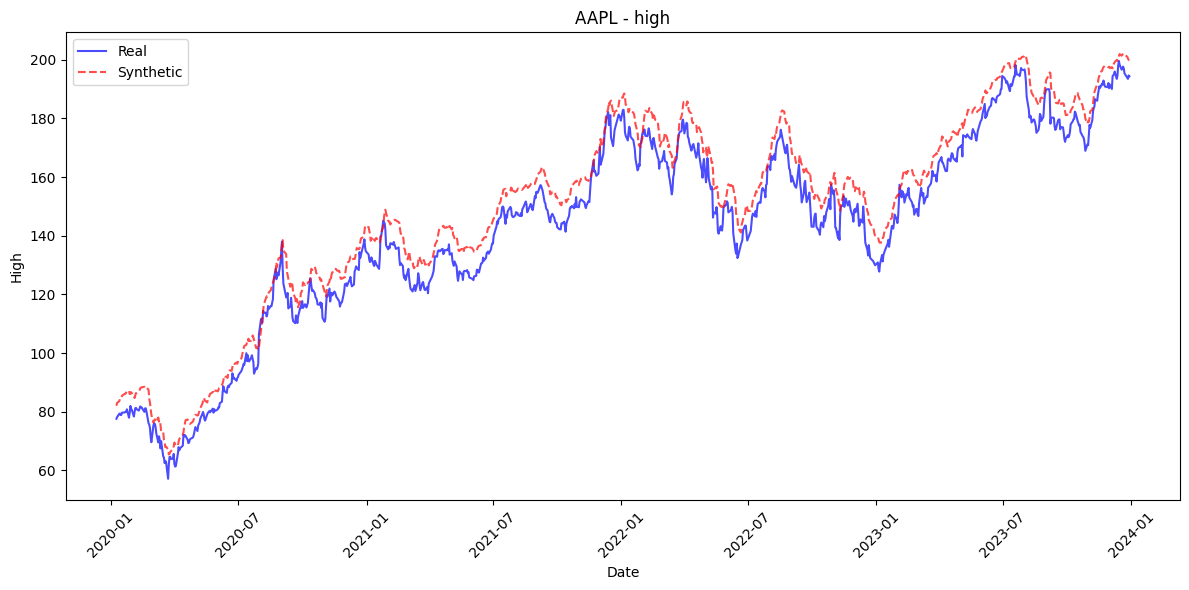

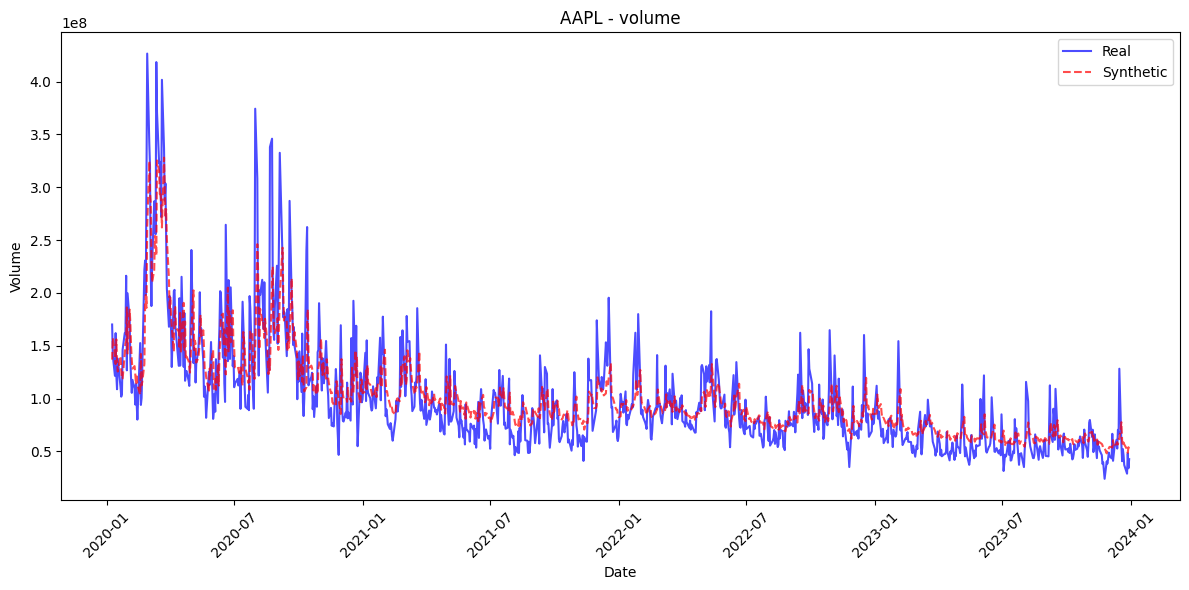

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Training MSFT...
Epoch 2, G Loss: 0.0814, D Loss: 0.6928
Epoch 4, G Loss: 0.0772, D Loss: 0.6927
Epoch 6, G Loss: 0.0750, D Loss: 0.6927
Epoch 8, G Loss: 0.0748, D Loss: 0.6925
Epoch 10, G Loss: 0.0736, D Loss: 0.6925


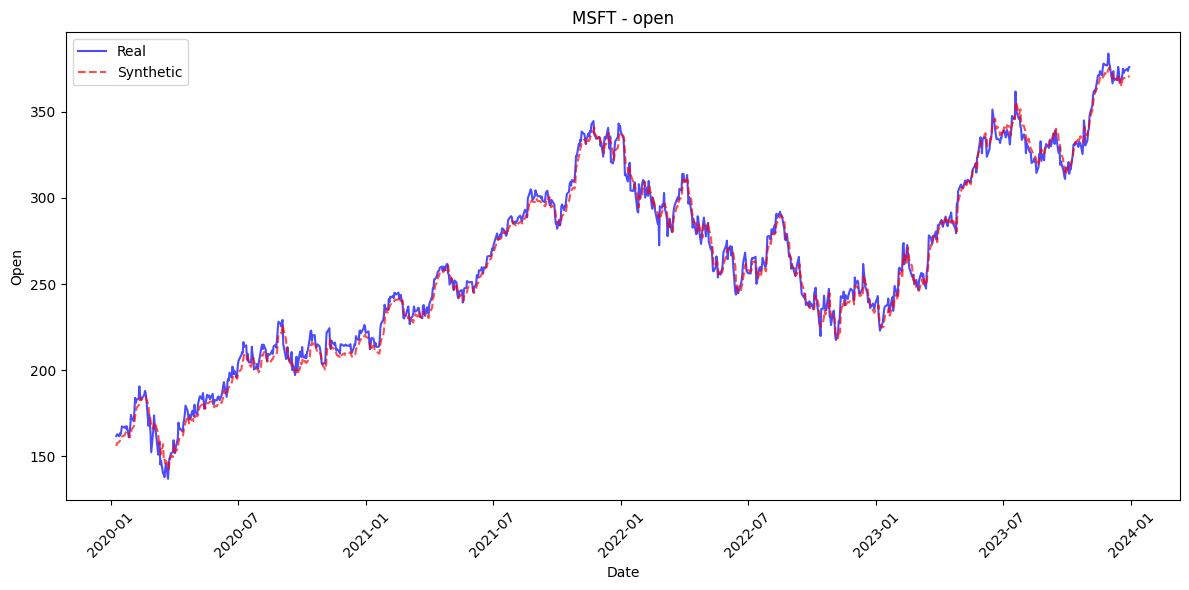

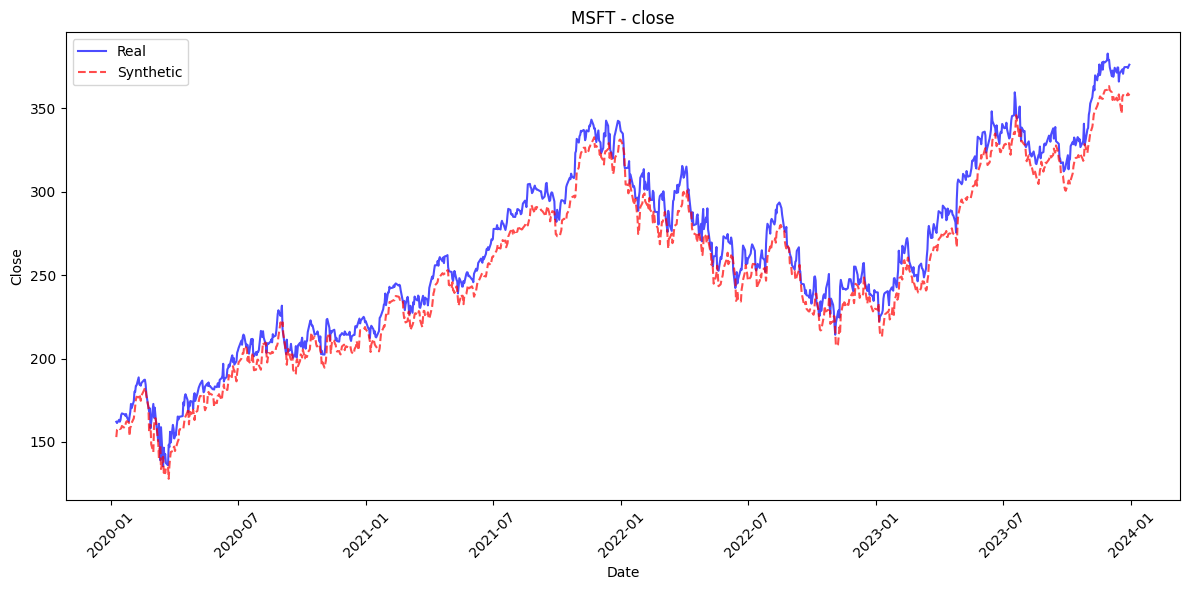

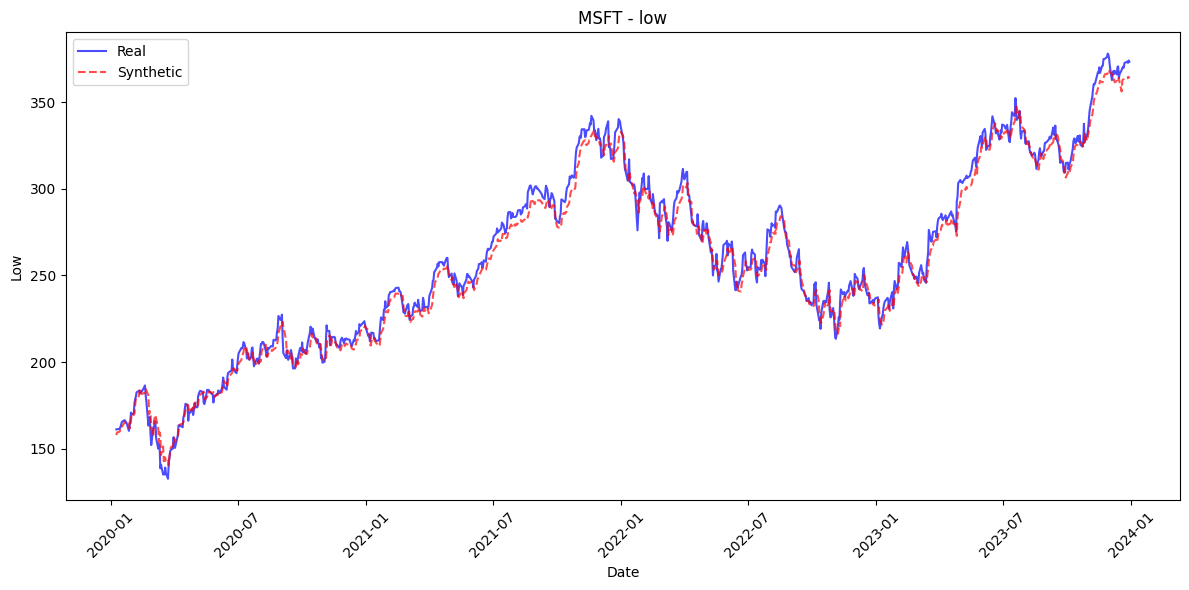

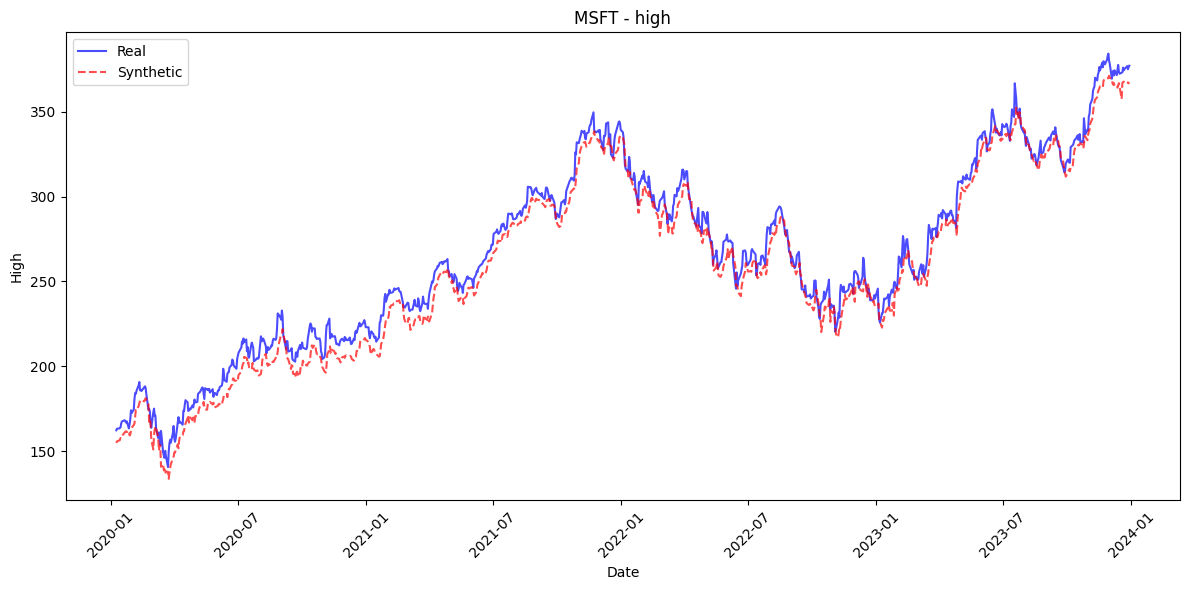

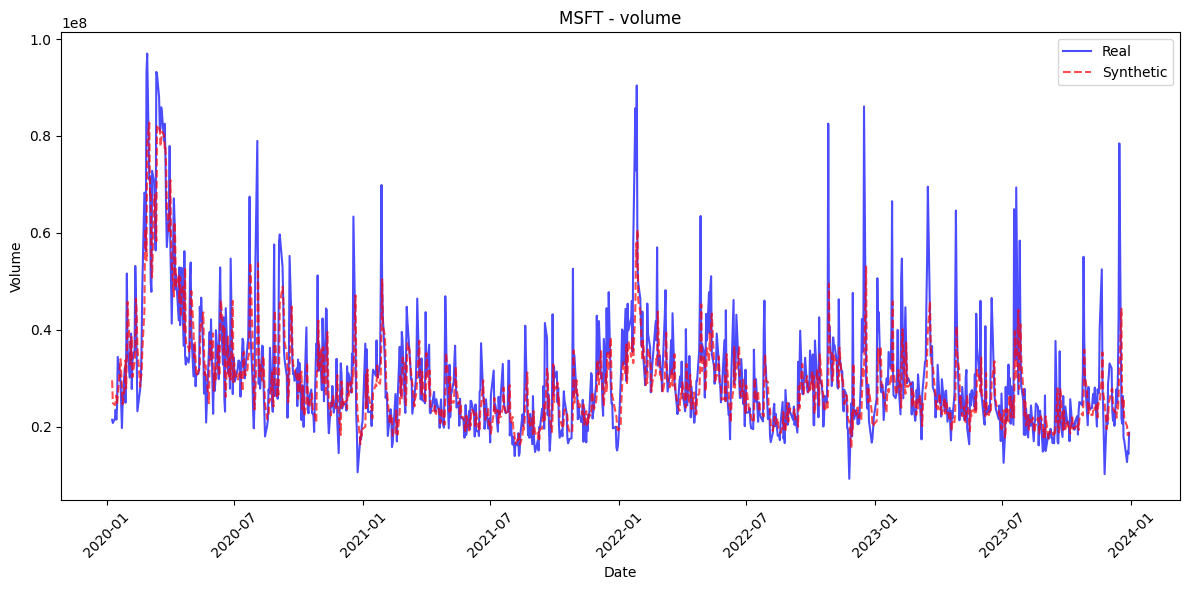

In [1]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime

class TransformerGenerator(nn.Module):
    def __init__(self, input_size, num_layers, d_model, nhead, dim_feedforward, output_size):
        super(TransformerGenerator, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src):
        # src shape: (batch_size, sequence_length, input_size)
        src = src.permute(1, 0, 2)  # (sequence_length, batch_size, input_size)
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[-1])  # Use the last time step
        return output

class Discriminator(nn.Module):
    def __init__(self, input_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

def train_gan_model(ticker, data, features, sequence_length=5, epochs=10, batch_size=32):
    # Get data for the ticker
    df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
    
    # Scaling
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    df_features = df_ticker[['date_ordinal', 'open', 'close', 'low', 'high', 'volume']]
    df_targets = df_ticker[features]
    
    feature_scaler.fit(df_features)
    target_scaler.fit(df_targets)
    
    scaled_features = feature_scaler.transform(df_features)
    scaled_targets = target_scaler.transform(df_targets)
    
    # Create sequences
    X = []
    y = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
        y.append(scaled_targets[i+sequence_length])
    
    X = np.array(X)
    y = np.array(y)
    
    # Prepare PyTorch datasets
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize models
    generator = TransformerGenerator(
        input_size=X.shape[2],
        num_layers=2,
        d_model=64,
        nhead=4,
        dim_feedforward=128,
        output_size=y.shape[1]
    )
    
    discriminator = Discriminator(input_size=y.shape[1])
    
    # Loss and optimizers
    criterion = nn.MSELoss()
    adversarial_loss = nn.BCELoss()
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)
    
    # Training
    print(f"\nTraining {ticker}...")
    for epoch in range(epochs):
        total_g_loss = 0
        total_d_loss = 0
        
        for batch_X, batch_y in dataloader:
            batch_size = batch_X.size(0)
            
            # Train Discriminator
            d_optimizer.zero_grad()
            
            # Real data
            real_labels = torch.ones(batch_size, 1)
            fake_labels = torch.zeros(batch_size, 1)
            
            outputs = discriminator(batch_y)
            d_loss_real = adversarial_loss(outputs, real_labels)
            
            # Fake data
            fake_data = generator(batch_X)
            outputs = discriminator(fake_data.detach())
            d_loss_fake = adversarial_loss(outputs, fake_labels)
            
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            
            # Generate and discriminate
            fake_data = generator(batch_X)
            g_loss_mse = criterion(fake_data, batch_y)  # MSE loss for accuracy
            
            outputs = discriminator(fake_data)
            g_loss_adv = adversarial_loss(outputs, real_labels)  # Adversarial loss
            
            g_loss = g_loss_mse + 0.1 * g_loss_adv  # Combine losses
            g_loss.backward()
            g_optimizer.step()
            
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}, G Loss: {total_g_loss/len(dataloader):.4f}, D Loss: {total_d_loss/len(dataloader):.4f}")
    
    # Generate predictions for comparison
    generator.eval()
    with torch.no_grad():
        X_pred = torch.tensor(X, dtype=torch.float32)
        y_pred = generator(X_pred)
        y_pred = y_pred.numpy()
    
    # Inverse transform predictions and actual targets
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_true_inv = target_scaler.inverse_transform(y)
    
    # Prepare comparison DataFrame with dates
    dates = df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)
    comparison_df = pd.DataFrame(y_true_inv, columns=features)
    comparison_df['date'] = dates
    for i, feature in enumerate(features):
        comparison_df[feature + '_synthetic'] = y_pred_inv[:, i]
    
    return comparison_df

def plot_comparisons(comparison_df, ticker, features):
    for feature in features:
        plt.figure(figsize=(12, 6))
        plt.plot(comparison_df['date'], comparison_df[feature], 
                label='Real', color='blue', alpha=0.7)
        plt.plot(comparison_df['date'], comparison_df[feature + '_synthetic'], 
                label='Synthetic', color='red', alpha=0.7, linestyle='--')
        plt.title(f"{ticker} - {feature}")
        plt.xlabel('Date')
        plt.ylabel(feature.capitalize())
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

def load_data(tickers, start_date, end_date):
    data_frames = []
    for ticker in tickers:
        df = yf.download(ticker, start=start_date, end=end_date)
        df.reset_index(inplace=True)
        df['ticker'] = ticker
        df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
        df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
        data_frames.append(df)
    return pd.concat(data_frames).reset_index(drop=True)



# Main execution
def main():
    # Parameters
    tickers = ['AAPL', 'MSFT']
    features = ['open', 'close', 'low', 'high', 'volume']
    start_date = '2020-01-01'
    end_date = '2023-12-31'
    
    # Load data
    print("Loading data...")
    data = load_data(tickers, start_date, end_date)
    
    # Convert date to ordinal for feature
    data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)
    
    # Process each ticker
    for ticker in tickers:
        comparison_df = train_gan_model(ticker, data, features)
        plot_comparisons(comparison_df, ticker, features)

if __name__ == "__main__":
    main()
# ```

# Key improvements while keeping it simple:

# 1. **Same Structure**: Kept the working Transformer structure but added GAN components
# 2. **Date Alignment**: Ensures synthetic data aligns with real dates
# 3. **Per-Ticker Processing**: Maintains separate scaling and processing for each ticker
# 4. **Proper Comparison**: Shows real vs synthetic for the same time period

# Main changes:
# 1. Added simple Discriminator
# 2. Modified loss function to include adversarial component
# 3. Added GAN training loop while keeping Transformer architecture
# 4. Improved plotting with date alignment

# To use:
# ```python
# main()
# ```

# This will:
# 1. Load data for specified tickers
# 2. Train GAN model for each ticker
# 3. Generate synthetic data
# 4. Plot comparisons with proper date alignment

# Would you like me to explain any part in more detail?

## Differential privacy

Loading data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Training AAPL with manual differential privacy...
Epoch 10, G Loss: 0.1005, D Loss: 0.6938
Epoch 20, G Loss: 0.0986, D Loss: 0.6917
Epoch 30, G Loss: 0.1008, D Loss: 0.6951
Epoch 40, G Loss: 0.1001, D Loss: 0.6946
Epoch 50, G Loss: 0.0988, D Loss: 0.6940
Epoch 60, G Loss: 0.1016, D Loss: 0.6941
Epoch 70, G Loss: 0.1074, D Loss: 0.6922
Epoch 80, G Loss: 0.1042, D Loss: 0.6940
Epoch 90, G Loss: 0.1065, D Loss: 0.6949
Epoch 100, G Loss: 0.1089, D Loss: 0.6919


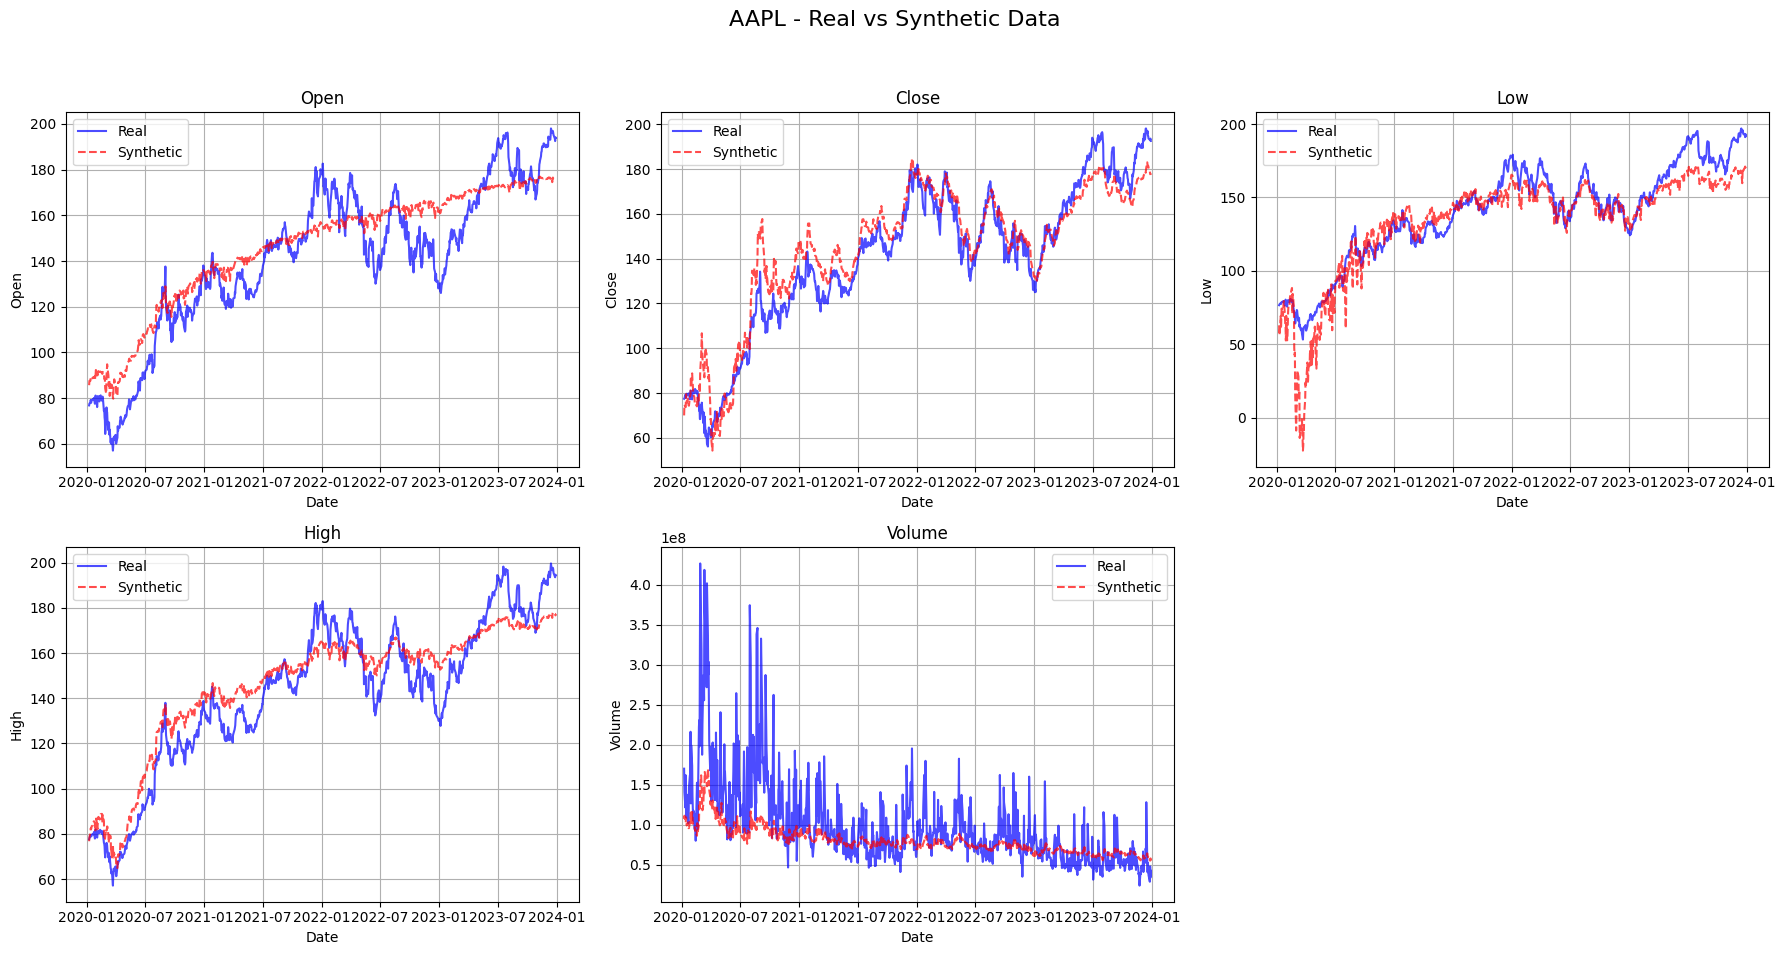

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Training MSFT with manual differential privacy...
Epoch 10, G Loss: 0.1266, D Loss: 0.6945
Epoch 20, G Loss: 0.1152, D Loss: 0.6933
Epoch 30, G Loss: 0.1165, D Loss: 0.6942
Epoch 40, G Loss: 0.1143, D Loss: 0.6929
Epoch 50, G Loss: 0.1119, D Loss: 0.6928
Epoch 60, G Loss: 0.1147, D Loss: 0.6929
Epoch 70, G Loss: 0.1145, D Loss: 0.6923
Epoch 80, G Loss: 0.1136, D Loss: 0.6923
Epoch 90, G Loss: 0.1150, D Loss: 0.6934
Epoch 100, G Loss: 0.1173, D Loss: 0.6916


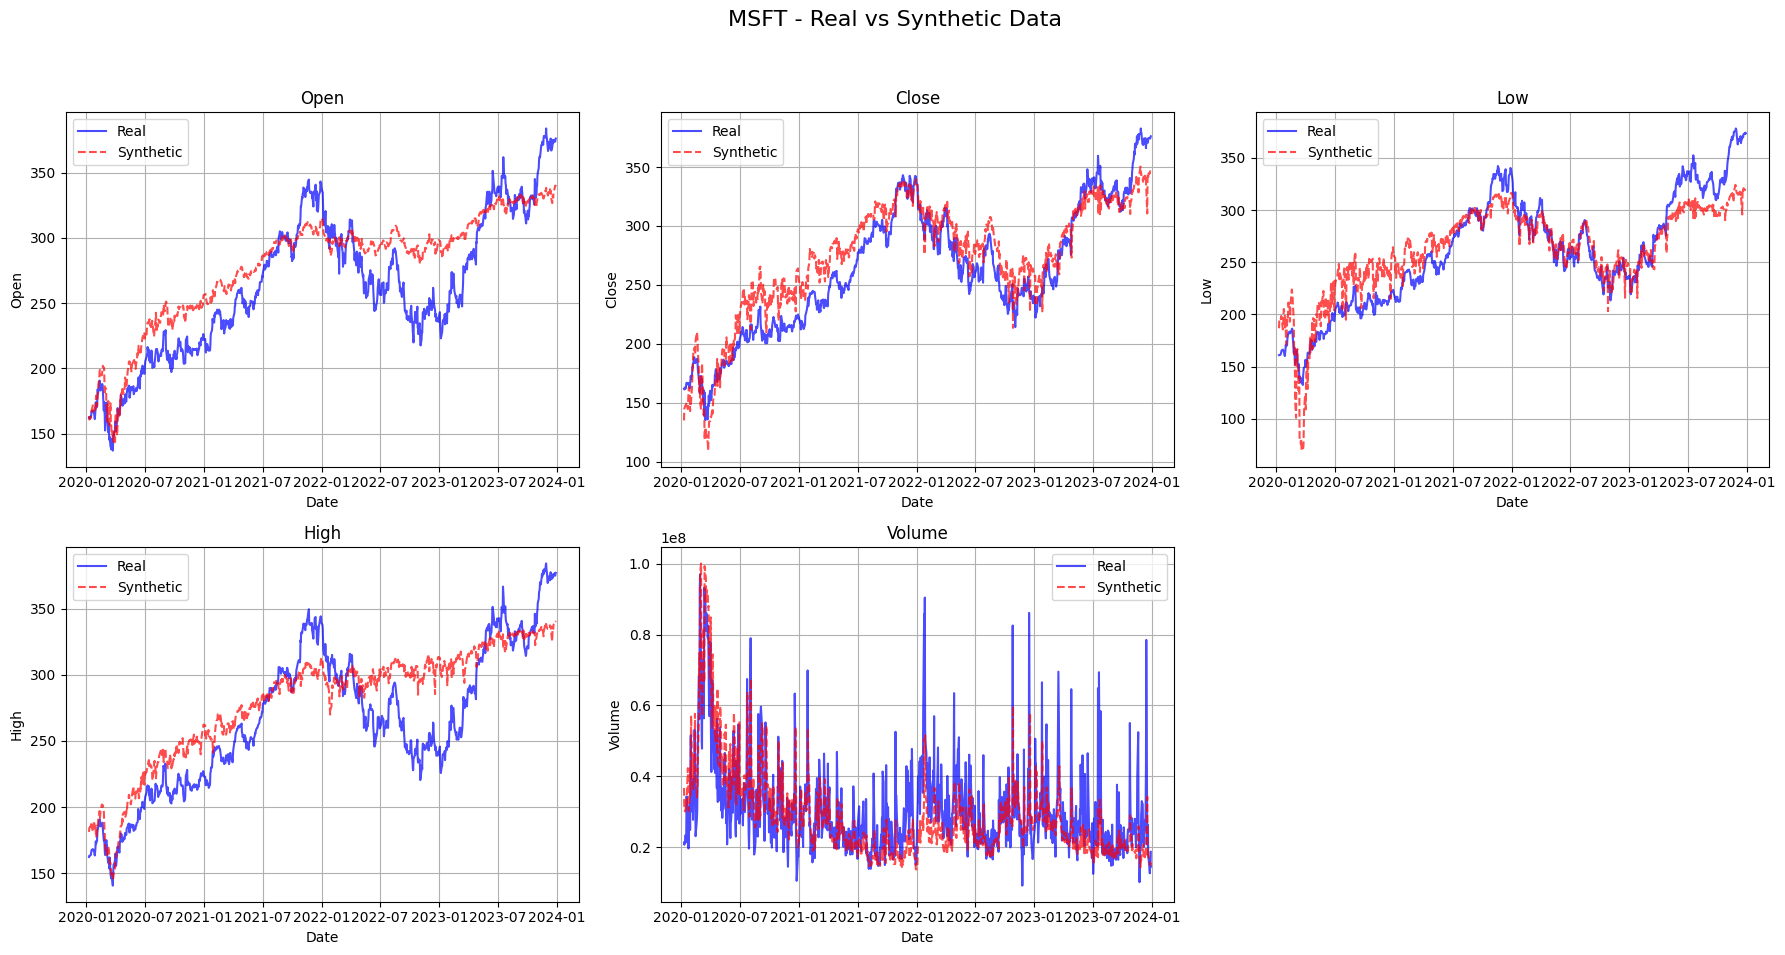

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Define the Generator model using Transformer
class TransformerGenerator(nn.Module):
    def __init__(self, input_size, num_layers, d_model, nhead, dim_feedforward, output_size):
        super(TransformerGenerator, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src):
        # src shape: (batch_size, sequence_length, input_size)
        src = src.permute(1, 0, 2)  # (sequence_length, batch_size, input_size)
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[-1])  # Use the last time step
        return output

# Define the Discriminator model
class Discriminator(nn.Module):
    def __init__(self, input_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Function to add noise to gradients manually
def add_noise_to_gradients(parameters, noise_scale):
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            noise = torch.normal(0, noise_scale, size=param.grad.shape, device=param.grad.device)
            param.grad += noise

# Function to clip gradients manually
def clip_gradients(parameters, max_grad_norm):
    total_norm = 0.0
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            param_norm = param.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5

    clip_coef = max_grad_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for param in parameters:
            if param.requires_grad and param.grad is not None:
                param.grad.data.mul_(clip_coef)

# GAN training function with manual differential privacy
def train_gan_with_manual_dp(ticker, data, features, sequence_length=5, epochs=100, batch_size=32, noise_scale=1.0, max_grad_norm=1.0):
    # Get data for the ticker
    df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
    
    # Scaling
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    df_features = df_ticker[['date_ordinal', 'open', 'close', 'low', 'high', 'volume']]
    df_targets = df_ticker[features]
    
    feature_scaler.fit(df_features)
    target_scaler.fit(df_targets)
    
    scaled_features = feature_scaler.transform(df_features)
    scaled_targets = target_scaler.transform(df_targets)
    
    # Create sequences
    X = []
    y = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
        y.append(scaled_targets[i+sequence_length])
    
    X = np.array(X)
    y = np.array(y)
    
    # Prepare PyTorch datasets
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Determine device (GPU or CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize models
    generator = TransformerGenerator(
        input_size=X.shape[2],
        num_layers=2,
        d_model=64,
        nhead=4,
        dim_feedforward=128,
        output_size=y.shape[1]
    ).to(device)

    discriminator = Discriminator(input_size=y.shape[1]).to(device)

    # Optimizers
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)

    # Loss functions
    criterion = nn.MSELoss()
    adversarial_loss = nn.BCELoss()
    
    # Training
    print(f"\nTraining {ticker} with manual differential privacy...")
    for epoch in range(epochs):
        total_g_loss = 0
        total_d_loss = 0
        
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            batch_size = batch_X.size(0)

            # Train Discriminator
            d_optimizer.zero_grad()

            # Real data
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            outputs = discriminator(batch_y)
            d_loss_real = adversarial_loss(outputs, real_labels)

            # Fake data
            fake_data = generator(batch_X)
            outputs = discriminator(fake_data.detach())
            d_loss_fake = adversarial_loss(outputs, fake_labels)

            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()

            # Clip and add noise to gradients
            clip_gradients(discriminator.parameters(), max_grad_norm)
            add_noise_to_gradients(discriminator.parameters(), noise_scale)

            d_optimizer.step()

            # Train Generator
            g_optimizer.zero_grad()

            # Generate and discriminate
            fake_data = generator(batch_X)
            g_loss_mse = criterion(fake_data, batch_y)  # MSE loss for accuracy

            outputs = discriminator(fake_data)
            g_loss_adv = adversarial_loss(outputs, real_labels)  # Adversarial loss

            g_loss = g_loss_mse + 0.1 * g_loss_adv  # Combine losses
            g_loss.backward()

            # Clip and add noise to gradients
            clip_gradients(generator.parameters(), max_grad_norm)
            add_noise_to_gradients(generator.parameters(), noise_scale)

            g_optimizer.step()

            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, G Loss: {total_g_loss/len(data_loader):.4f}, D Loss: {total_d_loss/len(data_loader):.4f}")

    # Generate predictions for comparison
    generator.eval()
    with torch.no_grad():
        X_pred = torch.tensor(X, dtype=torch.float32).to(device)
        y_pred = generator(X_pred)
        y_pred = y_pred.cpu().numpy()

    # Inverse transform predictions and actual targets
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_true_inv = target_scaler.inverse_transform(y)

    # Prepare comparison DataFrame with dates
    dates = df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)
    comparison_df = pd.DataFrame(y_true_inv, columns=features)
    comparison_df['date'] = dates
    for i, feature in enumerate(features):
        comparison_df[feature + '_synthetic'] = y_pred_inv[:, i]

    # Plot comparisons in grid format with 3 images per row
    plot_comparisons_grid(comparison_df, ticker, features)

# Plotting function for real vs. synthetic data in grid format with 3 images per row
def plot_comparisons_grid(comparison_df, ticker, features):
    rows = (len(features) + 2) // 3  # Calculate the number of rows needed for 3 plots per row
    fig, axs = plt.subplots(rows, 3, figsize=(18, rows * 5))
    fig.suptitle(f"{ticker} - Real vs Synthetic Data", fontsize=16)

    for idx, feature in enumerate(features):
        row, col = divmod(idx, 3)
        ax = axs[row, col] if rows > 1 else axs[col]
        ax.plot(comparison_df['date'], comparison_df[feature], label='Real', color='blue', alpha=0.7)
        ax.plot(comparison_df['date'], comparison_df[feature + '_synthetic'], label='Synthetic', color='red', alpha=0.7, linestyle='--')
        ax.set_title(f"{feature.capitalize()}")
        ax.set_xlabel('Date')
        ax.set_ylabel(feature.capitalize())
        ax.legend()
        ax.grid(True)

    # Hide empty subplots if any
    for idx in range(len(features), rows * 3):
        row, col = divmod(idx, 3)
        fig.delaxes(axs[row, col] if rows > 1 else axs[col])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Load and process data as per original script
def load_data(tickers, start_date, end_date):
    data_frames = []
    for ticker in tickers:
        df = yf.download(ticker, start=start_date, end=end_date)
        df.reset_index(inplace=True)
        df['ticker'] = ticker
        df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
        df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
        data_frames.append(df)
    return pd.concat(data_frames).reset_index(drop=True)

# Main function
def main():
    tickers = ['AAPL', 'MSFT']
    features = ['open', 'close', 'low', 'high', 'volume']
    start_date = '2020-01-01'
    end_date = '2023-12-31'

    print("Loading data...")
    data = load_data(tickers, start_date, end_date)

    data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)

    for ticker in tickers:
        train_gan_with_manual_dp(ticker, data, features)

if __name__ == "__main__":
    main()


Loading data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



Training GAN on all tickers combined with manual differential privacy...
Epoch 10, G Loss: 0.1010, D Loss: 0.6937
Epoch 20, G Loss: 0.1029, D Loss: 0.6939
Epoch 30, G Loss: 0.1043, D Loss: 0.6939
Epoch 40, G Loss: 0.1063, D Loss: 0.6945
Epoch 50, G Loss: 0.1164, D Loss: 0.6928
Epoch 60, G Loss: 0.1195, D Loss: 0.6926
Epoch 70, G Loss: 0.1194, D Loss: 0.6931
Epoch 80, G Loss: 0.1187, D Loss: 0.6925
Epoch 90, G Loss: 0.1185, D Loss: 0.6927
Epoch 100, G Loss: 0.1192, D Loss: 0.6916

Evaluation Metrics for AAPL:
Feature: open
  MSE: 171.2502
  Pearson Correlation: 0.9662
  Wasserstein Distance: 9.8812

Feature: close
  MSE: 323.5824
  Pearson Correlation: 0.9200
  Wasserstein Distance: 12.8934

Feature: low
  MSE: 125.3787
  Pearson Correlation: 0.9431
  Wasserstein Distance: 3.0272

Feature: high
  MSE: 456.4709
  Pearson Correlation: 0.9867
  Wasserstein Distance: 16.0437

Feature: volume
  MSE: 1467732475161514.5000
  Pearson Correlation: 0.7868
  Wasserstein Distance: 17551617.1848



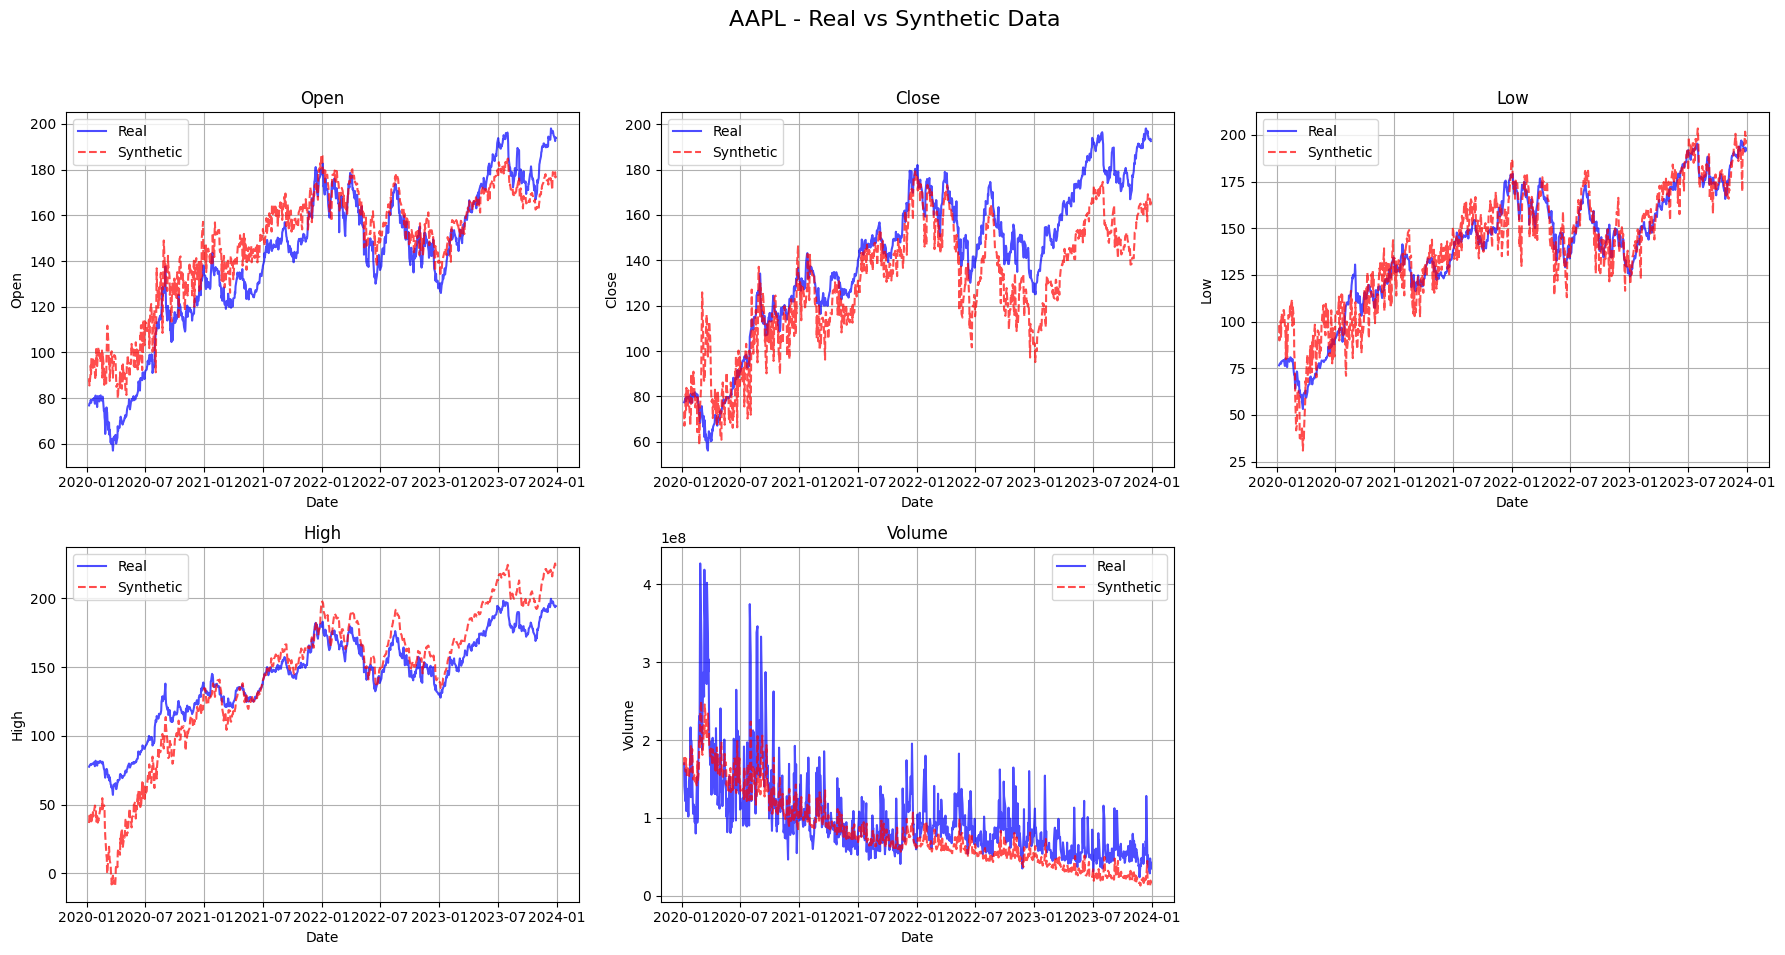

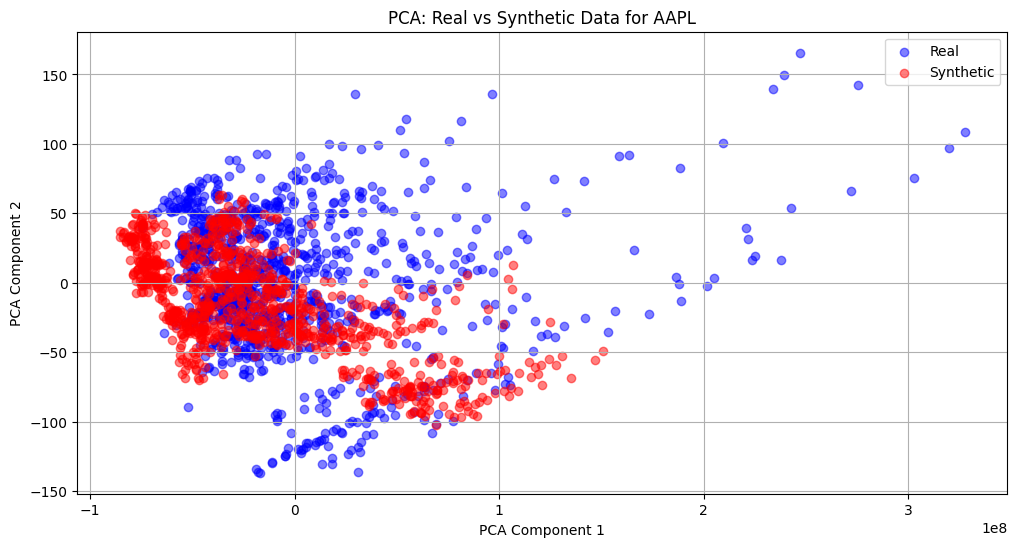

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


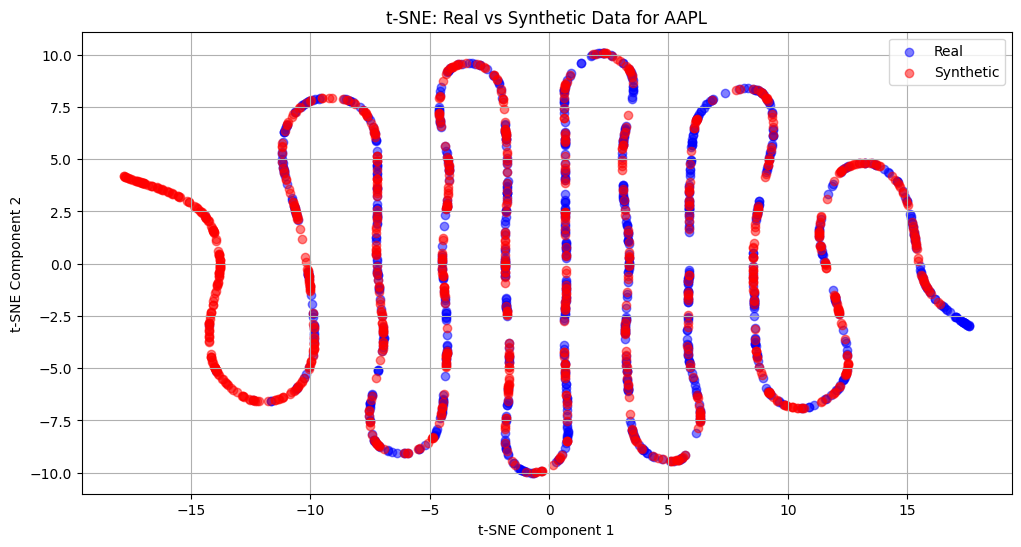


Evaluation Metrics for MSFT:
Feature: open
  MSE: 1065.6368
  Pearson Correlation: 0.9019
  Wasserstein Distance: 22.0313

Feature: close
  MSE: 959.6604
  Pearson Correlation: 0.9040
  Wasserstein Distance: 20.8650

Feature: low
  MSE: 578.0870
  Pearson Correlation: 0.9705
  Wasserstein Distance: 17.3905

Feature: high
  MSE: 561.0930
  Pearson Correlation: 0.9661
  Wasserstein Distance: 20.6962

Feature: volume
  MSE: 1446417015817798.0000
  Pearson Correlation: 0.4166
  Wasserstein Distance: 33438627.6663



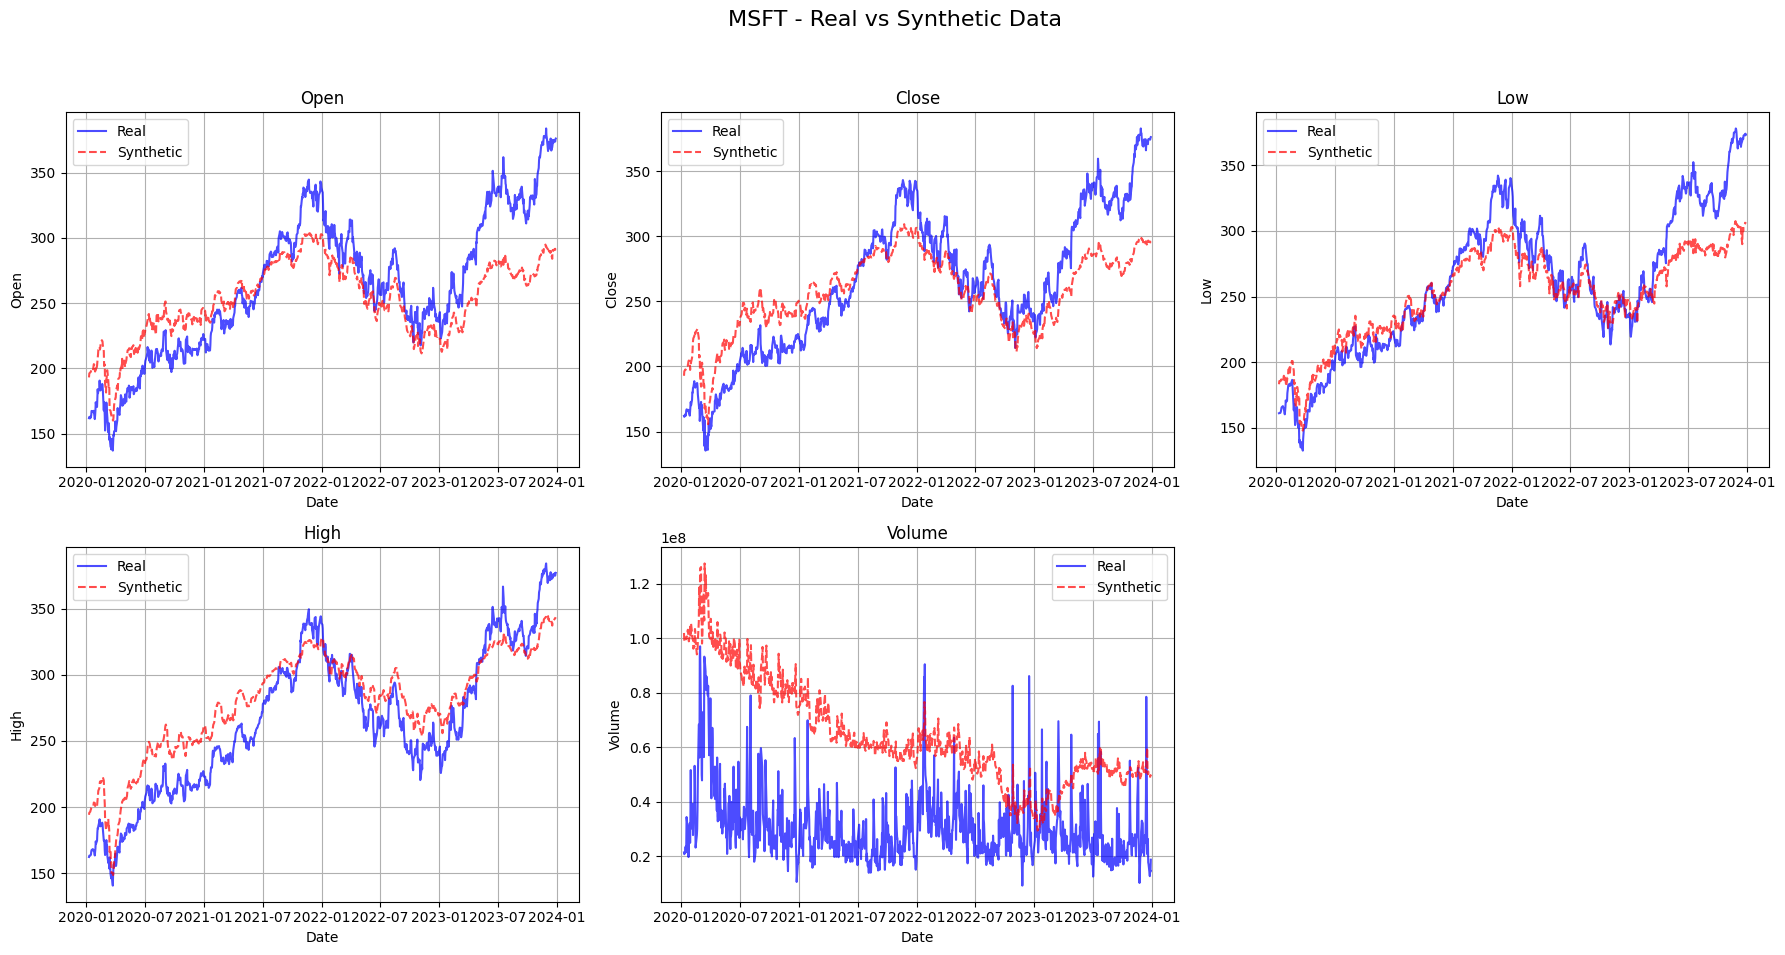

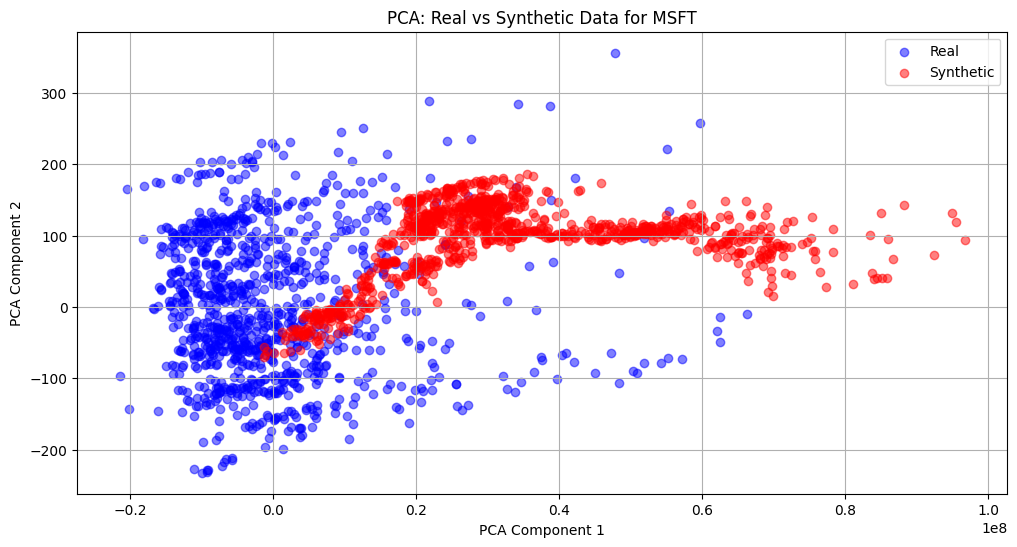

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


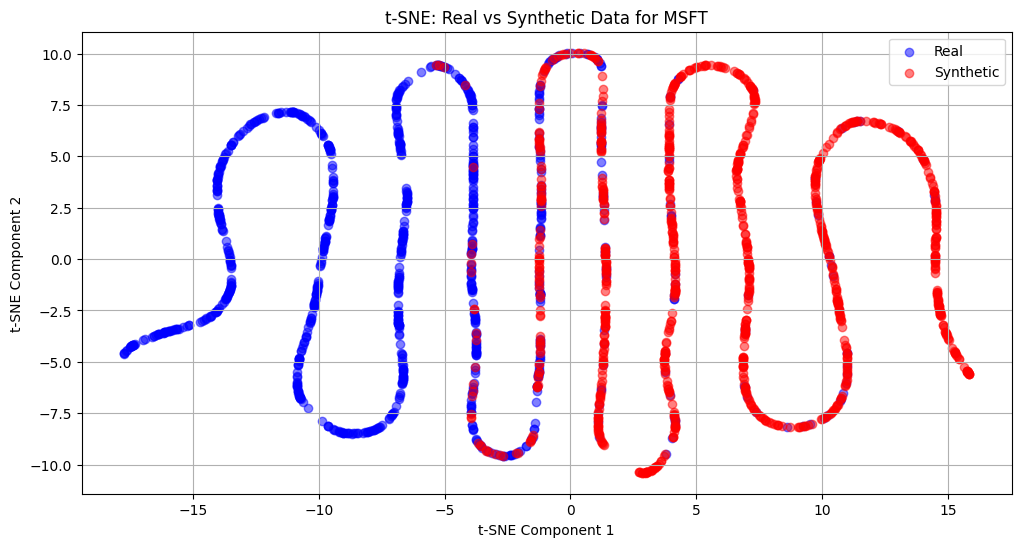

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import wasserstein_distance, pearsonr
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Define the Generator model using Transformer
class TransformerGenerator(nn.Module):
    def __init__(self, input_size, num_layers, d_model, nhead, dim_feedforward, output_size):
        super(TransformerGenerator, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src):
        # src shape: (batch_size, sequence_length, input_size)
        src = src.permute(1, 0, 2)  # (sequence_length, batch_size, input_size)
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[-1])  # Use the last time step
        return output

# Define the Discriminator model
class Discriminator(nn.Module):
    def __init__(self, input_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Function to add noise to gradients manually
def add_noise_to_gradients(parameters, noise_scale):
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            noise = torch.normal(0, noise_scale, size=param.grad.shape, device=param.grad.device)
            param.grad += noise

# Function to clip gradients manually
def clip_gradients(parameters, max_grad_norm):
    total_norm = 0.0
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            param_norm = param.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5

    clip_coef = max_grad_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for param in parameters:
            if param.requires_grad and param.grad is not None:
                param.grad.data.mul_(clip_coef)

# GAN training function for all tickers combined
def train_gan_with_manual_dp(data, features, sequence_length=5, epochs=100, batch_size=32, noise_scale=1.0, max_grad_norm=1.0):
    # Scaling
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    df_features = data[['date_ordinal', 'open', 'close', 'low', 'high', 'volume']]
    df_targets = data[features]
    
    feature_scaler.fit(df_features)
    target_scaler.fit(df_targets)
    
    scaled_features = feature_scaler.transform(df_features)
    scaled_targets = target_scaler.transform(df_targets)
    
    # Create sequences
    X = []
    y = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
        y.append(scaled_targets[i+sequence_length])
    
    X = np.array(X)
    y = np.array(y)
    
    # Prepare PyTorch datasets
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Determine device (GPU or CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize models
    generator = TransformerGenerator(
        input_size=X.shape[2],
        num_layers=2,
        d_model=64,
        nhead=4,
        dim_feedforward=128,
        output_size=y.shape[1]
    ).to(device)

    discriminator = Discriminator(input_size=y.shape[1]).to(device)

    # Optimizers
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)

    # Loss functions
    criterion = nn.MSELoss()
    adversarial_loss = nn.BCELoss()
    
    # Training
    print(f"\nTraining GAN on all tickers combined with manual differential privacy...")
    for epoch in range(epochs):
        total_g_loss = 0
        total_d_loss = 0
        
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            batch_size = batch_X.size(0)

            # Train Discriminator
            d_optimizer.zero_grad()

            # Real data
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            outputs = discriminator(batch_y)
            d_loss_real = adversarial_loss(outputs, real_labels)

            # Fake data
            fake_data = generator(batch_X)
            outputs = discriminator(fake_data.detach())
            d_loss_fake = adversarial_loss(outputs, fake_labels)

            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()

            # Clip and add noise to gradients
            clip_gradients(discriminator.parameters(), max_grad_norm)
            add_noise_to_gradients(discriminator.parameters(), noise_scale)

            d_optimizer.step()

            # Train Generator
            g_optimizer.zero_grad()

            # Generate and discriminate
            fake_data = generator(batch_X)
            g_loss_mse = criterion(fake_data, batch_y)  # MSE loss for accuracy

            outputs = discriminator(fake_data)
            g_loss_adv = adversarial_loss(outputs, real_labels)  # Adversarial loss

            g_loss = g_loss_mse + 0.1 * g_loss_adv  # Combine losses
            g_loss.backward()

            # Clip and add noise to gradients
            clip_gradients(generator.parameters(), max_grad_norm)
            add_noise_to_gradients(generator.parameters(), noise_scale)

            g_optimizer.step()

            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, G Loss: {total_g_loss/len(data_loader):.4f}, D Loss: {total_d_loss/len(data_loader):.4f}")

    return generator, feature_scaler, target_scaler, device

# Generate synthetic data for a specific ticker
def generate_synthetic_data(generator, df_ticker, feature_scaler, target_scaler, sequence_length, features, device):
    df_features = df_ticker[['date_ordinal', 'open', 'close', 'low', 'high', 'volume']]
    scaled_features = feature_scaler.transform(df_features)

    # Create sequences for predictions
    X = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
    
    X = np.array(X)
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    # Generate synthetic data
    generator.eval()
    with torch.no_grad():
        y_pred = generator(X_tensor)
        y_pred = y_pred.cpu().numpy()

    # Inverse transform predictions
    y_pred_inv = target_scaler.inverse_transform(y_pred)

    return y_pred_inv, df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)

# Evaluation function for synthetic data per ticker
def evaluate_generated_data(y_true, y_pred, features, ticker):
    print(f"\nEvaluation Metrics for {ticker}:")
    for i, feature in enumerate(features):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
        wasserstein = wasserstein_distance(y_true[:, i], y_pred[:, i])
        print(f"Feature: {feature}")
        print(f"  MSE: {mse:.4f}")
        print(f"  Pearson Correlation: {corr:.4f}")
        print(f"  Wasserstein Distance: {wasserstein:.4f}\n")

# PCA and t-SNE visualization function per ticker
def pca_tsne_visualization(y_true, y_pred, ticker):
    pca = PCA(n_components=2)
    true_pca = pca.fit_transform(y_true)
    pred_pca = pca.transform(y_pred)

    plt.figure(figsize=(12, 6))
    plt.scatter(true_pca[:, 0], true_pca[:, 1], label='Real', alpha=0.5, color='blue')
    plt.scatter(pred_pca[:, 0], pred_pca[:, 1], label='Synthetic', alpha=0.5, color='red')
    plt.title(f'PCA: Real vs Synthetic Data for {ticker}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

    tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
    combined_data = np.vstack((y_true, y_pred))
    tsne_result = tsne.fit_transform(combined_data)
    true_tsne = tsne_result[:y_true.shape[0]]
    pred_tsne = tsne_result[y_true.shape[0]:]

    plt.figure(figsize=(12, 6))
    plt.scatter(true_tsne[:, 0], true_tsne[:, 1], label='Real', alpha=0.5, color='blue')
    plt.scatter(pred_tsne[:, 0], pred_tsne[:, 1], label='Synthetic', alpha=0.5, color='red')
    plt.title(f't-SNE: Real vs Synthetic Data for {ticker}')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting function for real vs. synthetic data for each feature per ticker with 3 images per row
def plot_comparisons_grid(y_true, y_pred, dates, features, ticker):
    # Calculate number of rows needed to have 3 images per row
    rows = (len(features) + 2) // 3  # Add 2 to ensure we round up if len(features) isn't divisible by 3
    fig, axs = plt.subplots(rows, 3, figsize=(18, rows * 5))
    fig.suptitle(f"{ticker} - Real vs Synthetic Data", fontsize=16)

    # Make axs always iterable
    axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]

    for idx, feature in enumerate(features):
        ax = axs[idx]
        ax.plot(dates, y_true[:, idx], label='Real', color='blue', alpha=0.7)
        ax.plot(dates, y_pred[:, idx], label='Synthetic', color='red', alpha=0.7, linestyle='--')
        ax.set_title(f"{feature.capitalize()}")
        ax.set_xlabel('Date')
        ax.set_ylabel(feature.capitalize())
        ax.legend()
        ax.grid(True)

    # Hide any unused subplots
    for idx in range(len(features), len(axs)):
        fig.delaxes(axs[idx])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Load and process data
def load_data(tickers, start_date, end_date):
    data_frames = []
    for ticker in tickers:
        df = yf.download(ticker, start=start_date, end=end_date)
        df.reset_index(inplace=True)
        df['ticker'] = ticker
        df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
        df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
        data_frames.append(df)
    return pd.concat(data_frames).reset_index(drop=True)

# Main function
def main():
    tickers = ['AAPL', 'MSFT']
    features = ['open', 'close', 'low', 'high', 'volume']
    start_date = '2020-01-01'
    end_date = '2023-12-31'

    print("Loading data...")
    data = load_data(tickers, start_date, end_date)
    data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)

    # Train the GAN on all tickers combined
    generator, feature_scaler, target_scaler, device = train_gan_with_manual_dp(data, features)

    # Generate and evaluate synthetic data for each ticker separately
    for ticker in tickers:
        df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
        
        # Generate synthetic data using the trained model
        y_pred_inv, dates = generate_synthetic_data(generator, df_ticker, feature_scaler, target_scaler, sequence_length=5, features=features, device=device)
        
        # Extract true values for evaluation
        y_true_inv = df_ticker[features].iloc[5:].values

        # Evaluate generated data for the current ticker
        evaluate_generated_data(y_true_inv, y_pred_inv, features, ticker)

        # Plot comparisons for the current ticker
        plot_comparisons_grid(y_true_inv, y_pred_inv, dates, features, ticker)

        # PCA and t-SNE visualization for the current ticker
        pca_tsne_visualization(y_true_inv, y_pred_inv, ticker)

if __name__ == "__main__":
    main()


## Improvements for production

2024-11-26 12:00:11,360 - __main__ - INFO - Loaded and merged configuration from config.json
2024-11-26 12:00:11,362 - __main__ - INFO - Loading data...
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
2024-11-26 12:00:12,709 - __main__ - INFO - Training model...
2024-11-26 12:00:12,710 - __main__ - INFO - Training on device: cpu
/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
2024-11-26 12:00:57,668 - __main__ - INFO - Epoch 10, G Loss: 0.2248, D Loss: 0.7109, LR: 0.000500
2024-11-26 12:00:57,691 - __main__ - INFO - Privacy metrics at epoch 9:
2024-11-26 12:00:57,692 - __main__ - INFO -   Privacy Score: -41.2885
2024-11-26 12:00:57,692 - __main__ - INFO

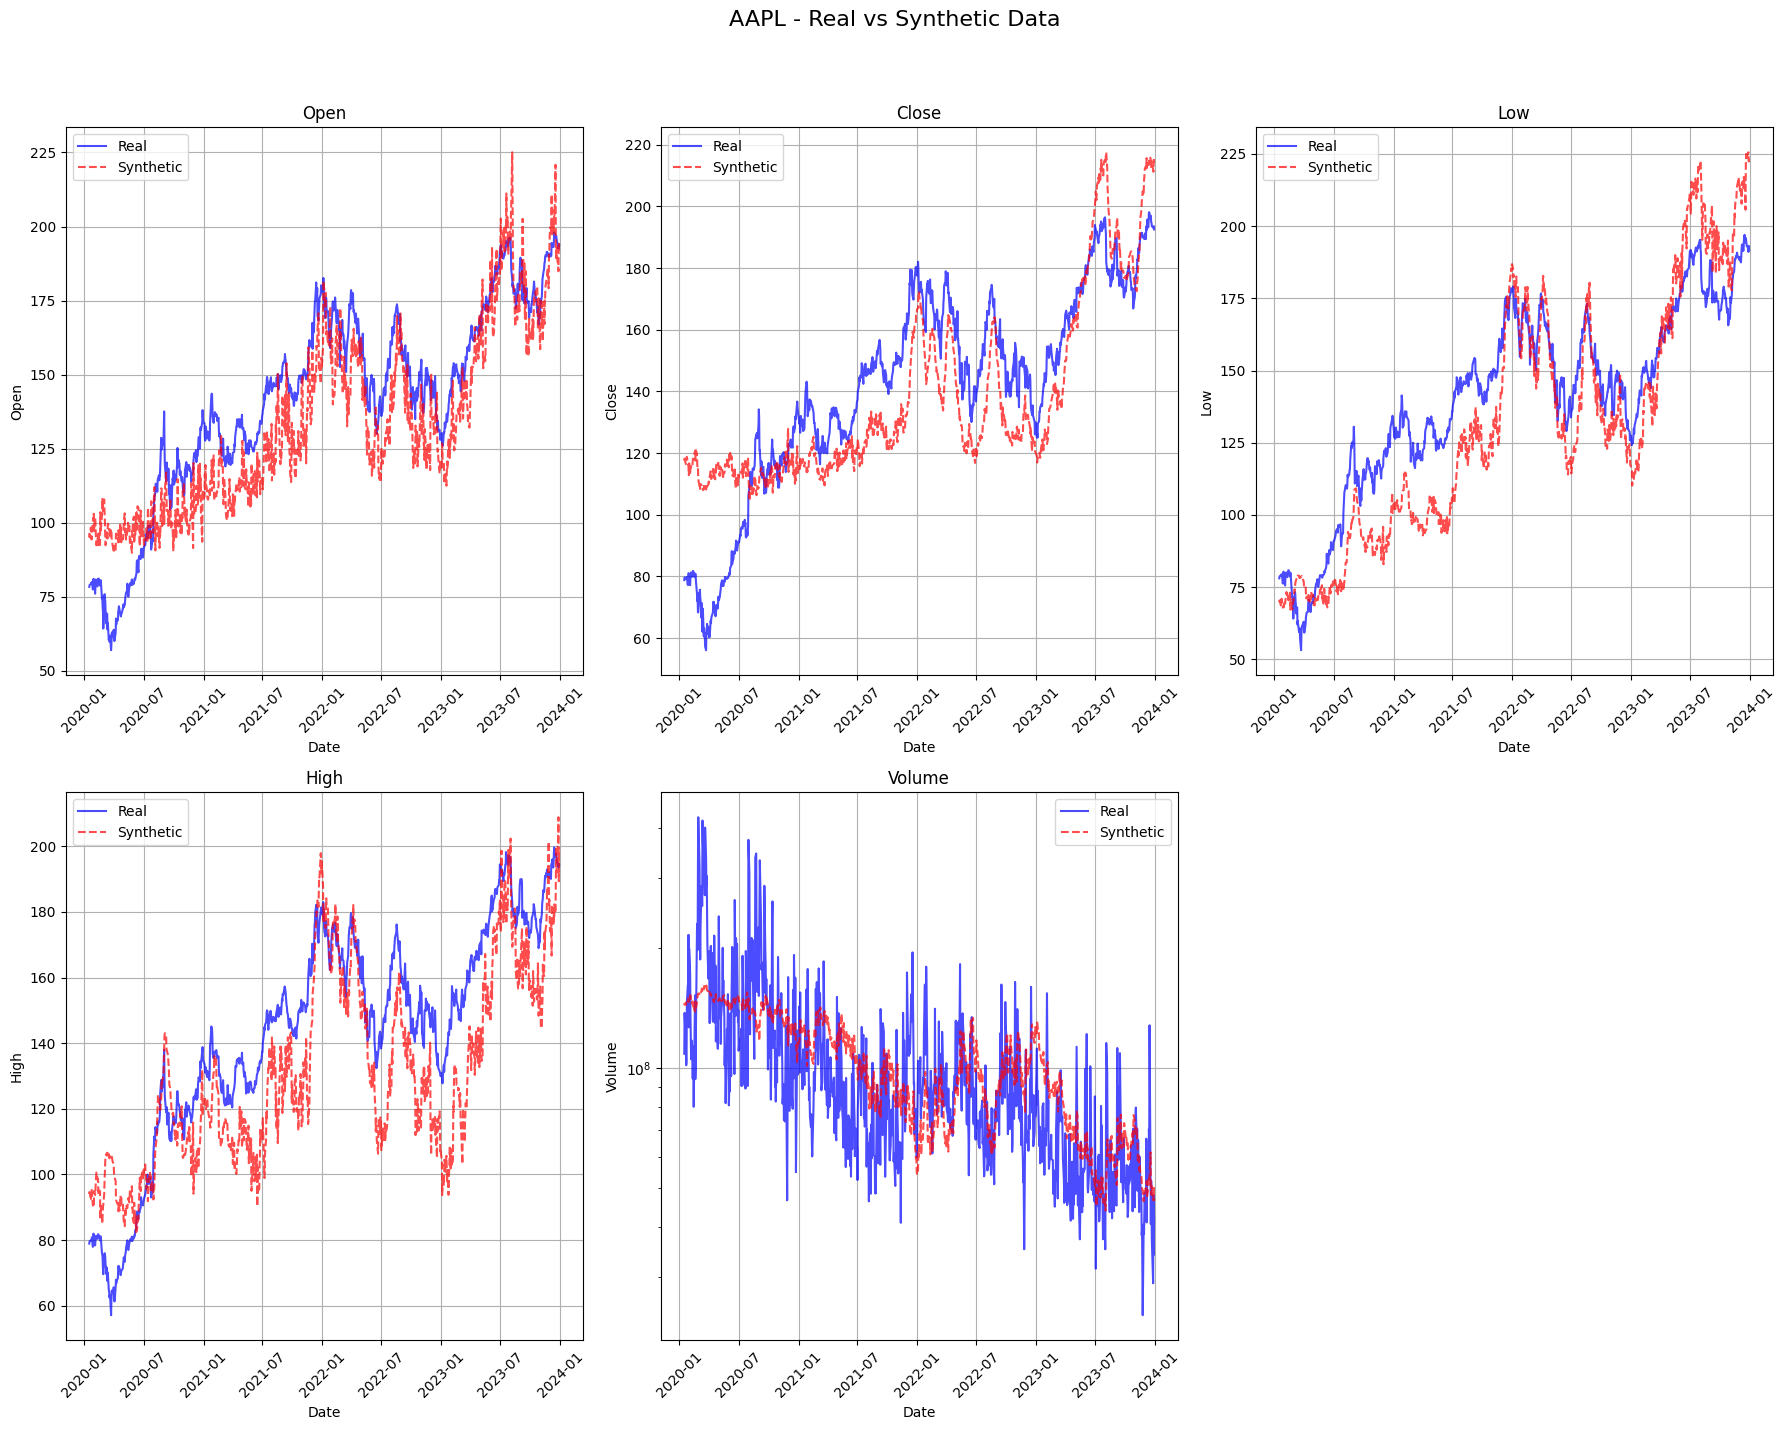

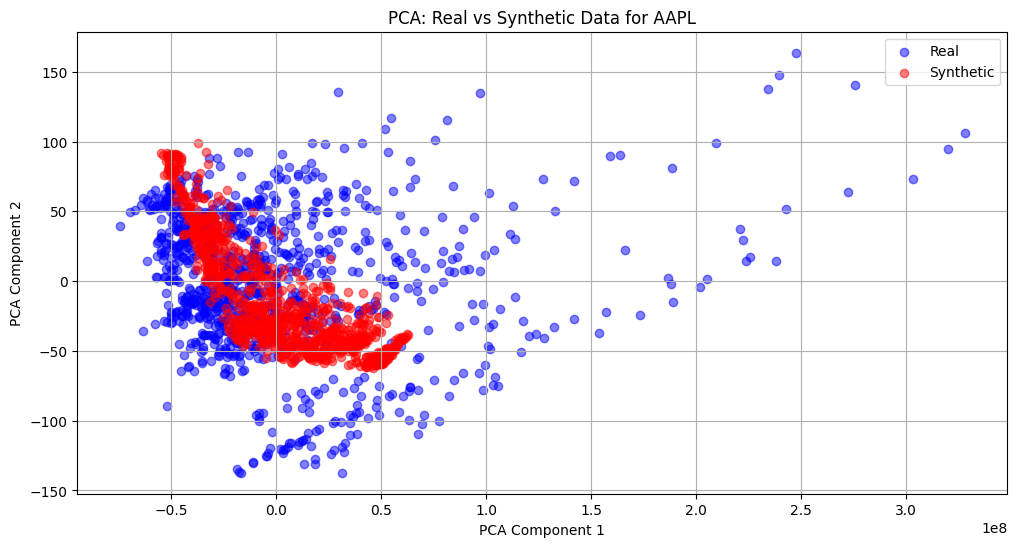

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


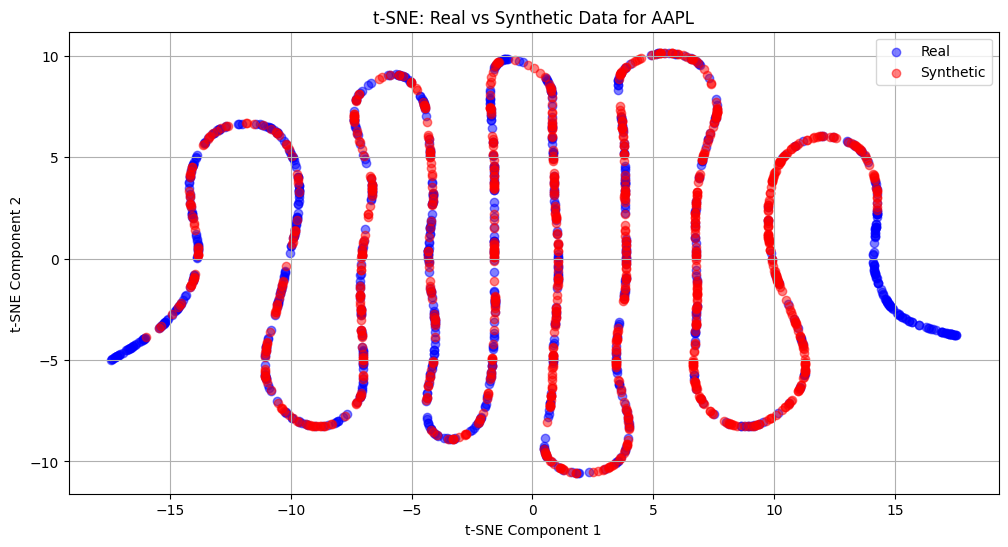

2024-11-26 12:08:17,347 - __main__ - INFO - Processing MSFT...
2024-11-26 12:08:17,480 - __main__ - INFO - 
Evaluation Metrics for MSFT:
2024-11-26 12:08:17,486 - __main__ - INFO - Feature: open
2024-11-26 12:08:17,487 - __main__ - INFO -   MSE: 939.1799
2024-11-26 12:08:17,488 - __main__ - INFO -   Pearson Correlation: 0.8666
2024-11-26 12:08:17,489 - __main__ - INFO -   Wasserstein Distance: 25.4363

2024-11-26 12:08:17,496 - __main__ - INFO - Feature: close
2024-11-26 12:08:17,497 - __main__ - INFO -   MSE: 636.5894
2024-11-26 12:08:17,498 - __main__ - INFO -   Pearson Correlation: 0.8955
2024-11-26 12:08:17,499 - __main__ - INFO -   Wasserstein Distance: 20.0834

2024-11-26 12:08:17,505 - __main__ - INFO - Feature: low
2024-11-26 12:08:17,506 - __main__ - INFO -   MSE: 622.1075
2024-11-26 12:08:17,507 - __main__ - INFO -   Pearson Correlation: 0.8949
2024-11-26 12:08:17,509 - __main__ - INFO -   Wasserstein Distance: 19.9018

2024-11-26 12:08:17,514 - __main__ - INFO - Feature: hig

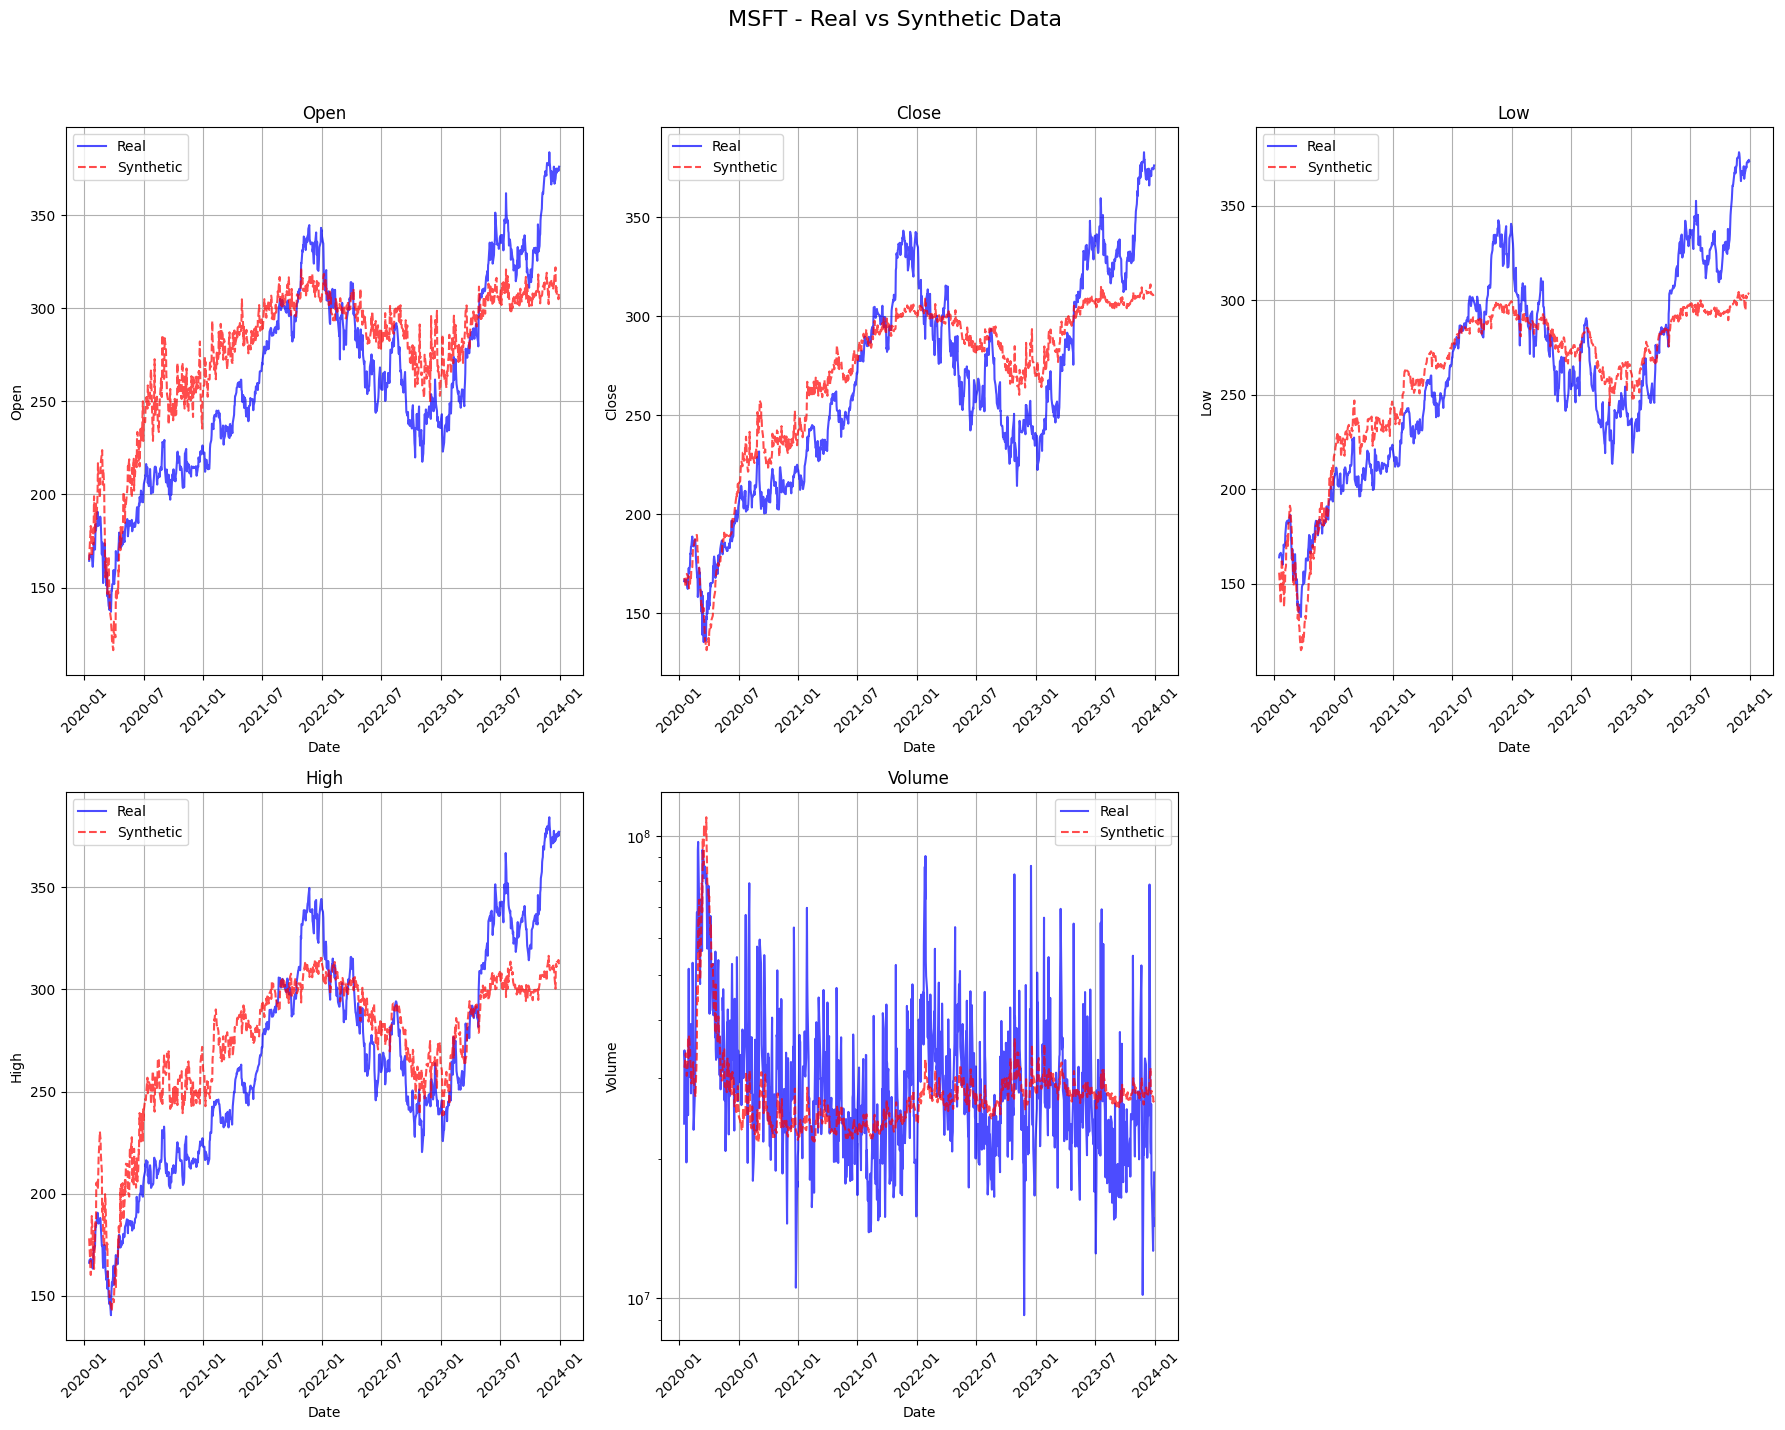

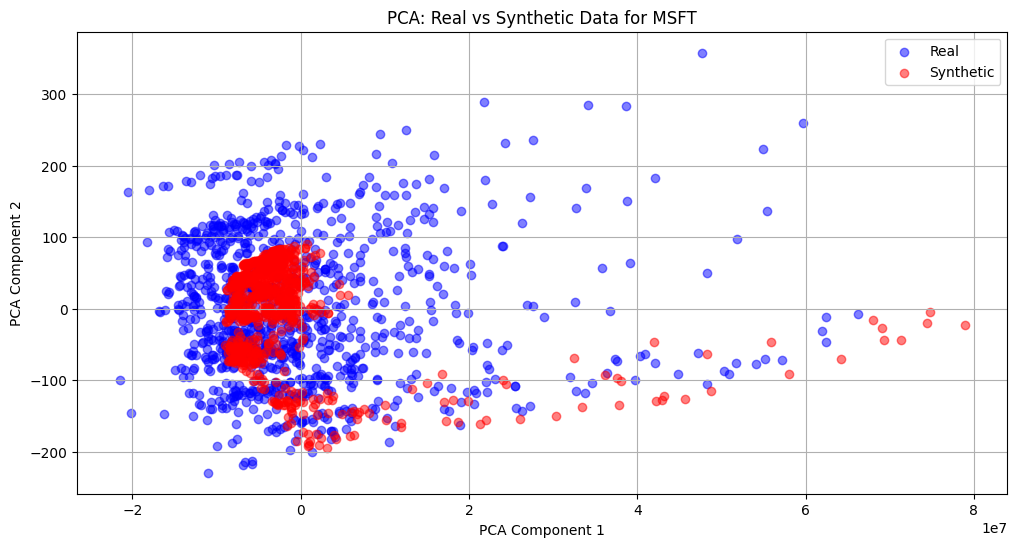

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


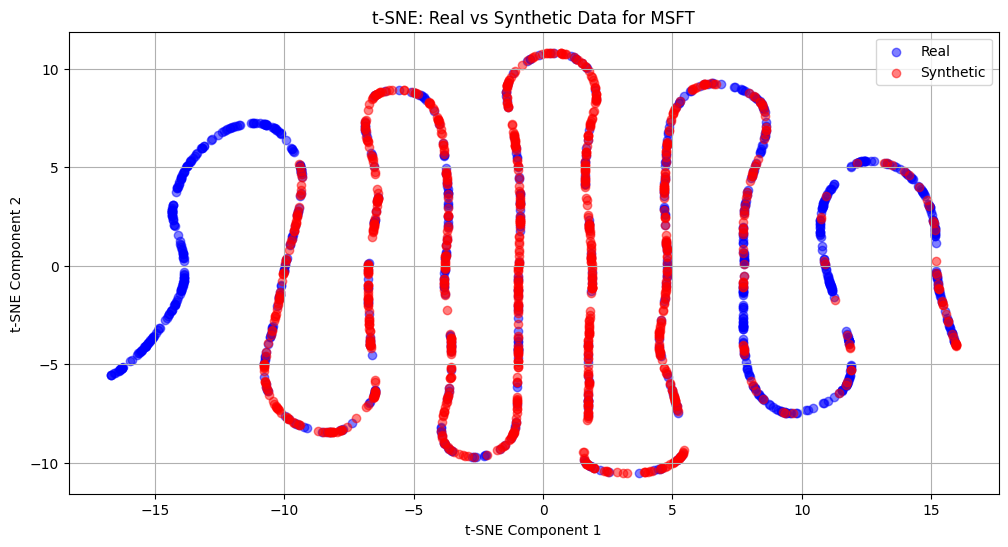

2024-11-26 12:08:27,814 - __main__ - INFO - Processing completed successfully


In [1]:
"""
Financial Time Series Generation using GAN with Differential Privacy.

This module implements a GAN-based approach for generating synthetic financial time series data
with differential privacy guarantees. It uses a Transformer-based generator and an enhanced
discriminator with proper gradient clipping and noise addition for privacy preservation.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import wasserstein_distance, pearsonr
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime
import random
from pathlib import Path
import logging
from typing import Tuple, List, Dict, Optional, Union, Iterator, Any, TypeVar, Callable
import json
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist
import os
from opendp.mod import enable_features

# Type variables
T = TypeVar('T')
ModelType = TypeVar('ModelType', bound=nn.Module)
DataType = TypeVar('DataType', pd.DataFrame, np.ndarray, torch.Tensor)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def set_seeds(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility.
    
    Args:
        seed: Integer seed for random number generators
        
    Note:
        Sets seeds for Python's random, NumPy, and PyTorch (CPU and CUDA)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def setup_distributed() -> Tuple[torch.device, int]:
    """
    Setup distributed training environment.
    
    Returns:
        Tuple containing:
            - PyTorch device (cuda or cpu)
            - Rank of the current process
            
    Note:
        Initializes distributed training if environment variables are set
    """
    if torch.cuda.is_available():
        if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
            rank = int(os.environ['RANK'])
            world_size = int(os.environ['WORLD_SIZE'])
            dist.init_process_group(backend='nccl', rank=rank, world_size=world_size)
            device = torch.device(f'cuda:{rank}')
            return device, rank
        else:
            return torch.device('cuda'), 0
    return torch.device('cpu'), 0

def setup_environment(
    config: Dict[str, Any],
    checkpoint_dir: str,
    output_dir: str
) -> None:
    """
    Setup training environment.
    
    Args:
        config: Configuration dictionary
        checkpoint_dir: Directory for checkpoints
        output_dir: Directory for outputs
        
    Raises:
        RuntimeError: If environment setup fails
    """
    try:
        # Set random seeds
        set_seeds(config["seed"])
        
        # Create directories
        for directory in [checkpoint_dir, output_dir]:
            Path(directory).mkdir(parents=True, exist_ok=True)
            
    except Exception as e:
        logger.error(f"Error setting up environment: {str(e)}")
        raise RuntimeError(f"Environment setup failed: {str(e)}")

def clip_gradients(parameters: Iterator[nn.Parameter], max_grad_norm: float) -> None:
    """
    Clip gradients by global norm for stable training.
    
    Args:
        parameters: Iterator of model parameters
        max_grad_norm: Maximum allowed norm of the gradients
        
    Returns:
        None
        
    Note:
        Modifies gradients in-place to ensure their global norm does not exceed max_grad_norm
    """
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    
    total_norm: float = 0.0
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            param_norm = param.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5

    clip_coef = max_grad_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for param in parameters:
            if param.requires_grad and param.grad is not None:
                param.grad.data.mul_(clip_coef)

def add_noise_to_gradients(parameters: Iterator[nn.Parameter], noise_scale: float) -> None:
    """
    Add Gaussian noise to gradients for differential privacy.
    
    Args:
        parameters: Iterator of model parameters
        noise_scale: Standard deviation of the Gaussian noise
        
    Returns:
        None
        
    Note:
        Modifies gradients in-place by adding random noise for privacy preservation
    """
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            noise = torch.normal(
                mean=0.0,
                std=noise_scale,
                size=param.grad.shape,
                device=param.grad.device
            )
            param.grad.data.add_(noise)

class CombinedScaler:
    """
    Custom scaler that handles dates, prices, and volume separately with appropriate scaling.
    
    Attributes:
        date_scaler: MinMaxScaler for date ordinals
        price_scaler: RobustScaler for price features
        volume_scaler: RobustScaler for volume features
        price_features: List of price-related feature names
        volume_features: List of volume-related feature names
    """
    
    def __init__(
        self, 
        date_scaler: MinMaxScaler, 
        price_scaler: RobustScaler, 
        volume_scaler: RobustScaler
    ) -> None:
        """
        Initialize the combined scaler.
        
        Args:
            date_scaler: Scaler for dates
            price_scaler: Scaler for price features
            volume_scaler: Scaler for volume features
        """
        self.date_scaler = date_scaler
        self.price_scaler = price_scaler
        self.volume_scaler = volume_scaler
        self.price_features: List[str] = ['open', 'close', 'low', 'high']
        self.volume_features: List[str] = ['volume']
    
    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """
        Transform the input data using appropriate scaling for each feature type.
        
        Args:
            X: Input DataFrame containing dates, prices, and volume
            
        Returns:
            Transformed array with scaled features
            
        Note:
            Applies log1p transformation to volume before scaling
        """
        dates = self.date_scaler.transform(X[['date_ordinal']])
        prices = self.price_scaler.transform(X[self.price_features])
        volume = self.volume_scaler.transform(np.log1p(X[self.volume_features]))
        return np.hstack([dates, prices, volume])
    
    def inverse_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Inverse transform the scaled data back to original scale.
        
        Args:
            X: Array of transformed values
            
        Returns:
            Array with original-scale features
            
        Note:
            Applies expm1 transformation to volume after inverse scaling
        """
        n_date_features = 1
        n_price_features = len(self.price_features)
        n_volume_features = len(self.volume_features)
        
        dates = X[:, :n_date_features]
        prices = X[:, n_date_features:n_date_features + n_price_features]
        volume = X[:, -n_volume_features:]
        
        dates = self.date_scaler.inverse_transform(dates)
        prices = self.price_scaler.inverse_transform(prices)
        volume = np.expm1(self.volume_scaler.inverse_transform(volume))
        
        return np.hstack([dates, prices, volume])

class TransformerGenerator(nn.Module):
    """
    Transformer-based generator model for synthetic data generation.
    
    Attributes:
        input_size: Dimension of input features
        positional_encoding: Linear layer for encoding input features
        transformer_encoder: TransformerEncoder for sequence processing
        decoder: Linear layer for output generation
    """
    
    def __init__(
        self, 
        input_size: int,
        num_layers: int,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        output_size: int,
        dropout: float = 0.1
    ) -> None:
        """
        Initialize the generator.
        
        Args:
            input_size: Number of input features
            num_layers: Number of transformer layers
            d_model: Dimension of the model
            nhead: Number of heads in multi-head attention
            dim_feedforward: Dimension of feedforward network
            output_size: Number of output features
            dropout: Dropout rate
        """
        super(TransformerGenerator, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the generator.
        
        Args:
            src: Input tensor of shape (batch_size, sequence_length, input_size)
            
        Returns:
            Output tensor of shape (batch_size, output_size)
        """
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[:, -1, :])
        return output
    
class EnhancedDiscriminator(nn.Module):
    """
    Enhanced discriminator with dropout and batch normalization.
    
    Attributes:
        model: Sequential model containing linear layers with batch norm and dropout
    """
    
    def __init__(
        self, 
        input_size: int, 
        hidden_sizes: List[int] = [128, 64, 32]
    ) -> None:
        """
        Initialize the discriminator.
        
        Args:
            input_size: Number of input features
            hidden_sizes: List of hidden layer sizes
        """
        super(EnhancedDiscriminator, self).__init__()
        layers = []
        current_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(current_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.3)
            ])
            current_size = hidden_size
        
        layers.extend([
            nn.Linear(hidden_sizes[-1], 1),
            nn.Sigmoid()
        ])
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the discriminator.
        
        Args:
            x: Input tensor
            
        Returns:
            Probability of input being real
        """
        return self.model(x)

class EarlyStopping:
    """
    Early stopping handler to prevent overfitting.
    
    Attributes:
        patience: Number of epochs to wait before stopping
        min_delta: Minimum change in monitored value
        counter: Number of epochs with no improvement
        best_loss: Best loss achieved
        early_stop: Whether to stop training
    """
    
    def __init__(self, patience: int = 10, min_delta: float = 0.001) -> None:
        """
        Initialize early stopping.
        
        Args:
            patience: Number of epochs to wait
            min_delta: Minimum change in monitored value
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss: Optional[float] = None
        self.early_stop = False
    
    def __call__(self, val_loss: float) -> bool:
        """
        Check if training should stop.
        
        Args:
            val_loss: Current validation loss
            
        Returns:
            Boolean indicating whether to stop training
        """
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

def setup_distributed() -> Tuple[torch.device, int]:
    """
    Setup distributed training environment.
    
    Returns:
        Tuple of (device, rank)
        
    Note:
        Returns CPU device and rank 0 if CUDA is not available
    """
    if torch.cuda.is_available():
        if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
            rank = int(os.environ['RANK'])
            world_size = int(os.environ['WORLD_SIZE'])
            dist.init_process_group(backend='nccl', rank=rank, world_size=world_size)
            device = torch.device(f'cuda:{rank}')
            return device, rank
        else:
            return torch.device('cuda'), 0
    return torch.device('cpu'), 0

def save_checkpoint(
    state: Dict[str, Any],
    is_best: bool,
    checkpoint_dir: str,
    filename: str = 'checkpoint.pth.tar'
) -> None:
    """
    Save model checkpoint.
    
    Args:
        state: State dictionary to save
        is_best: Whether this is the best model so far
        checkpoint_dir: Directory to save checkpoint
        filename: Name of checkpoint file
    """
    filepath = Path(checkpoint_dir) / filename
    torch.save(state, filepath)
    if is_best:
        best_filepath = Path(checkpoint_dir) / 'model_best.pth.tar'
        torch.save(state, best_filepath)

def load_checkpoint(
    checkpoint_path: str,
    generator: ModelType,
    discriminator: ModelType
) -> Dict[str, Any]:
    """
    Load model checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        generator: Generator model
        discriminator: Discriminator model
        
    Returns:
        Checkpoint state dictionary
        
    Raises:
        FileNotFoundError: If checkpoint file doesn't exist
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    return checkpoint

def get_lr_scheduler(
    optimizer: torch.optim.Optimizer, 
    config: Dict[str, Any]
) -> torch.optim.lr_scheduler.ReduceLROnPlateau:
    """
    Create learning rate scheduler with plateau detection.
    
    Args:
        optimizer: PyTorch optimizer instance
        config: Configuration dictionary containing scheduler parameters
        
    Returns:
        ReduceLROnPlateau scheduler
        
    Note:
        Expects config to contain 'training_params' with:
            - scheduler_patience: Number of epochs to wait before reducing LR
            - scheduler_factor: Factor by which to reduce LR
    """
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=config['training_params']['scheduler_patience'],
        factor=config['training_params']['scheduler_factor'],
        verbose=True
    )

def warmup_learning_rate(
    epoch: int, 
    warmup_epochs: int, 
    base_lr: float
) -> float:
    """
    Calculate learning rate during warmup period.
    
    Args:
        epoch: Current epoch number
        warmup_epochs: Number of warmup epochs
        base_lr: Base learning rate to reach after warmup
        
    Returns:
        Calculated learning rate for current epoch
        
    Note:
        Learning rate increases linearly from 0 to base_lr during warmup
    """
    if epoch >= warmup_epochs:
        return base_lr
    return base_lr * (epoch + 1) / warmup_epochs

def train_gan_with_manual_dp(
    data: pd.DataFrame,
    features: List[str],
    sequence_length: int = 10,
    epochs: int = 200,
    batch_size: int = 64,
    noise_scale: float = 0.5,
    max_grad_norm: float = 1.0,
    checkpoint_dir: str = 'checkpoints',
    patience: int = 20,
    config: Dict[str, Any] = None
) -> Tuple[nn.Module, CombinedScaler, torch.device]:
    """
    Train GAN with manual differential privacy, learning rate scheduling, and enhanced features.
    
    Args:
        data: Input DataFrame with financial time series data
        features: List of feature names to use
        sequence_length: Length of input sequences for temporal modeling
        epochs: Maximum number of training epochs
        batch_size: Size of training batches
        noise_scale: Scale of noise for differential privacy
        max_grad_norm: Maximum gradient norm for clipping
        checkpoint_dir: Directory to save checkpoints
        patience: Number of epochs to wait before early stopping
        config: Configuration dictionary with model and training parameters
        
    Returns:
        Tuple containing:
            - Trained generator model
            - Combined scaler for data transformation
            - Device used for training
            
    Raises:
        RuntimeError: If training fails
        ValueError: If input data or parameters are invalid
        
    Note:
        Implements several advanced training features:
            - Learning rate warmup
            - Gradient clipping and noise addition for privacy
            - Learning rate scheduling based on loss plateaus
            - Early stopping
            - Model checkpointing
            - Separate scaling for different feature types
    """
    # Validate inputs
    if config is None:
        raise ValueError("Configuration dictionary must be provided")
    if len(data) <= sequence_length:
        raise ValueError("Data length must be greater than sequence length")
    
    try:
        # Setup distributed training
        device, rank = setup_distributed()
        logger.info(f"Training on device: {device}")
        
        # Create checkpoint directory
        Path(checkpoint_dir).mkdir(exist_ok=True)
        
        # Initialize scalers
        price_features = [f for f in features if f not in ['volume', 'date_ordinal']]
        volume_features = ['volume'] if 'volume' in features else []
        
        date_scaler = MinMaxScaler()
        price_scaler = RobustScaler()
        volume_scaler = RobustScaler()
        
        # Scale features separately
        df_dates = data[['date_ordinal']]
        df_prices = data[price_features] if price_features else pd.DataFrame()
        df_volume = data[volume_features] if volume_features else pd.DataFrame()
        
        scaled_dates = date_scaler.fit_transform(df_dates)
        scaled_prices = price_scaler.fit_transform(df_prices) if not df_prices.empty else np.array([])
        scaled_volume = volume_scaler.fit_transform(np.log1p(df_volume)) if not df_volume.empty else np.array([])
        
        # Combine scaled features
        scaled_features_list = [scaled_dates]
        if not df_prices.empty:
            scaled_features_list.append(scaled_prices)
        if not df_volume.empty:
            scaled_features_list.append(scaled_volume)
            
        scaled_features = np.hstack(scaled_features_list)
        
        # Initialize combined scaler
        combined_scaler = CombinedScaler(date_scaler, price_scaler, volume_scaler)
        
        # Create sequences
        X: List[np.ndarray] = []
        y: List[np.ndarray] = []
        
        for i in range(len(scaled_features) - sequence_length):
            X.append(scaled_features[i:i+sequence_length])
            y.append(scaled_features[i+sequence_length])
        
        X_array = np.array(X)
        y_array = np.array(y)
        
        # Prepare PyTorch datasets
        X_tensor = torch.tensor(X_array, dtype=torch.float32)
        y_tensor = torch.tensor(y_array, dtype=torch.float32)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        data_loader = DataLoader(
            dataset, 
            batch_size=batch_size, 
            shuffle=True,
            num_workers=4,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        # Initialize models
        generator = TransformerGenerator(
            input_size=X_array.shape[2],
            num_layers=config['model_params']['generator']['num_layers'],
            d_model=config['model_params']['generator']['d_model'],
            nhead=config['model_params']['generator']['nhead'],
            dim_feedforward=config['model_params']['generator']['dim_feedforward'],
            output_size=y_array.shape[1],
            dropout=config['model_params']['generator']['dropout']
        ).to(device)
        
        discriminator = EnhancedDiscriminator(
            input_size=y_array.shape[1],
            hidden_sizes=config['model_params']['discriminator']['hidden_sizes']
        ).to(device)
        
        # Wrap models with DDP if using multiple GPUs
        if torch.cuda.device_count() > 1:
            generator = DDP(generator)
            discriminator = DDP(discriminator)
        
        # Optimizers
        g_optimizer = torch.optim.Adam(
            generator.parameters(), 
            lr=config['training_params']['g_learning_rate']
        )
        d_optimizer = torch.optim.Adam(
            discriminator.parameters(), 
            lr=config['training_params']['d_learning_rate']
        )
        
        # Schedulers
        g_scheduler = get_lr_scheduler(g_optimizer, config)
        d_scheduler = get_lr_scheduler(d_optimizer, config)
        
        # Loss functions
        criterion = nn.MSELoss()
        adversarial_loss = nn.BCELoss()
        
        # Early stopping
        early_stopping = EarlyStopping(patience=patience)
        
        # Training
        best_g_loss = float('inf')
        
        for epoch in range(epochs):
            # Warmup learning rate
            if epoch < config['training_params']['warmup_epochs']:
                for g_param_group in g_optimizer.param_groups:
                    g_param_group['lr'] = warmup_learning_rate(
                        epoch,
                        config['training_params']['warmup_epochs'],
                        config['training_params']['g_learning_rate']
                    )
                for d_param_group in d_optimizer.param_groups:
                    d_param_group['lr'] = warmup_learning_rate(
                        epoch,
                        config['training_params']['warmup_epochs'],
                        config['training_params']['d_learning_rate']
                    )
            
            total_g_loss = 0.0
            total_d_loss = 0.0
            
            generator.train()
            discriminator.train()
            
            for batch_X, batch_y in data_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                batch_size = batch_X.size(0)
                
                # Train Discriminator
                d_optimizer.zero_grad()
                
                # Real data
                real_labels = torch.ones(batch_size, 1).to(device)
                fake_labels = torch.zeros(batch_size, 1).to(device)
                
                outputs = discriminator(batch_y)
                d_loss_real = adversarial_loss(outputs, real_labels)
                
                # Fake data
                fake_data = generator(batch_X)
                outputs = discriminator(fake_data.detach())
                d_loss_fake = adversarial_loss(outputs, fake_labels)
                
                d_loss = (d_loss_real + d_loss_fake) / 2
                d_loss.backward()
                
                # Apply DP to discriminator
                clip_gradients(discriminator.parameters(), max_grad_norm)
                add_noise_to_gradients(discriminator.parameters(), noise_scale)
                
                d_optimizer.step()
                
                # Train Generator
                g_optimizer.zero_grad()
                
                fake_data = generator(batch_X)
                g_loss_mse = criterion(fake_data, batch_y)
                
                outputs = discriminator(fake_data)
                g_loss_adv = adversarial_loss(outputs, real_labels)
                
                # Combined loss with configurable adversarial weight
                g_loss = g_loss_mse + config['training_params']['adv_weight'] * g_loss_adv
                g_loss.backward()
                
                # Apply DP to generator
                clip_gradients(generator.parameters(), max_grad_norm)
                add_noise_to_gradients(generator.parameters(), noise_scale)
                
                g_optimizer.step()
                
                total_g_loss += g_loss.item()
                total_d_loss += d_loss.item()
            
            avg_g_loss = total_g_loss / len(data_loader)
            avg_d_loss = total_d_loss / len(data_loader)
            
            # Update schedulers
            g_scheduler.step(avg_g_loss)
            d_scheduler.step(avg_d_loss)
            
            if rank == 0:  # Only log on main process
                if (epoch + 1) % 10 == 0:
                    logger.info(
                        f"Epoch {epoch+1}, "
                        f"G Loss: {avg_g_loss:.4f}, "
                        f"D Loss: {avg_d_loss:.4f}, "
                        f"LR: {g_optimizer.param_groups[0]['lr']:.6f}"
                    )

                    try:
                        # Evaluate privacy metrics
                        privacy_metrics = test_privacy_strength(
                            generator,
                            discriminator,
                            batch_X,  # Ensure batch_X is properly shaped and normalized
                            noise_scale
                        )
                        logger.info(f"Privacy metrics at epoch {epoch}:")
                        logger.info(f"  Privacy Score: {privacy_metrics['privacy_score']:.4f}")
                        logger.info(f"  DP Strength: {privacy_metrics['dp_strength']}")
                    except Exception as e:
                        logger.error(f"Error calculating privacy metrics: {str(e)}")

                # Save checkpoint
                is_best = avg_g_loss < best_g_loss
                best_g_loss = min(avg_g_loss, best_g_loss)
                
                save_checkpoint({
                    'epoch': epoch,
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'g_optimizer_state_dict': g_optimizer.state_dict(),
                    'd_optimizer_state_dict': d_optimizer.state_dict(),
                    'g_scheduler_state_dict': g_scheduler.state_dict(),
                    'd_scheduler_state_dict': d_scheduler.state_dict(),
                    'g_loss': avg_g_loss,
                    'd_loss': avg_d_loss,
                    'config': config
                }, is_best, checkpoint_dir)
            
            # Early stopping
            if early_stopping(avg_g_loss):
                logger.info("Early stopping triggered")
                break
        
        # Load best model
        best_checkpoint = load_checkpoint(
            os.path.join(checkpoint_dir, 'model_best.pth.tar'),
            generator,
            discriminator
        )
        
        return generator, combined_scaler, device
        
    except Exception as e:
        logger.error(f"Training failed: {str(e)}")
        raise RuntimeError(f"Training failed: {str(e)}")

def evaluate_generated_data(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    features: List[str],
    ticker: str
) -> Dict[str, Dict[str, float]]:
    """
    Evaluate generated data against real data using multiple metrics.
    
    Args:
        y_true: True values array
        y_pred: Predicted values array
        features: List of feature names
        ticker: Ticker symbol
        
    Returns:
        Dictionary containing evaluation metrics for each feature:
            - MSE
            - Pearson correlation
            - Wasserstein distance
            
    Raises:
        ValueError: If input shapes don't match or features are invalid
    """
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    if len(features) != y_true.shape[1]:
        raise ValueError(f"Feature count mismatch: {len(features)} != {y_true.shape[1]}")
    
    metrics: Dict[str, Dict[str, float]] = {}
    logger.info(f"\nEvaluation Metrics for {ticker}:")
    
    for i, feature in enumerate(features):
        try:
            mse = mean_squared_error(y_true[:, i], y_pred[:, i])
            corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
            wasserstein = wasserstein_distance(y_true[:, i], y_pred[:, i])
            
            metrics[feature] = {
                'mse': mse,
                'correlation': corr,
                'wasserstein': wasserstein
            }
            
            logger.info(f"Feature: {feature}")
            logger.info(f"  MSE: {mse:.4f}")
            logger.info(f"  Pearson Correlation: {corr:.4f}")
            logger.info(f"  Wasserstein Distance: {wasserstein:.4f}\n")
            
        except Exception as e:
            logger.error(f"Error evaluating feature {feature}: {str(e)}")
            metrics[feature] = {
                'mse': float('nan'),
                'correlation': float('nan'),
                'wasserstein': float('nan')
            }
    
    return metrics

def plot_comparisons_grid(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: pd.Series,
    features: List[str],
    ticker: str,
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (18, 15)
) -> None:
    """
    Plot comparisons between real and synthetic data in a grid layout.

    Args:
        y_true: True values array
        y_pred: Predicted values array
        dates: Series of dates
        features: List of feature names
        ticker: Ticker symbol
        save_path: Optional path to save the plot
        figsize: Figure size (width, height)
        
    Raises:
        ValueError: If input dimensions don't match
    """
    if len(features) == 0:
        raise ValueError("No features provided for plotting")
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    
    try:
        rows = (len(features) + 2) // 3
        fig, axs = plt.subplots(rows, 3, figsize=figsize)
        fig.suptitle(f"{ticker} - Real vs Synthetic Data", fontsize=16)
        
        axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
        
        for idx, feature in enumerate(features):
            ax = axs[idx]
            
            # Handle volume differently
            if feature.lower() == 'volume':
                ax.set_yscale('log')
            
            ax.plot(dates, y_true[:, idx], label='Real', color='blue', alpha=0.7)
            ax.plot(dates, y_pred[:, idx], label='Synthetic', color='red', 
                   alpha=0.7, linestyle='--')
            ax.set_title(f"{feature.capitalize()}")
            ax.set_xlabel('Date')
            ax.set_ylabel(feature.capitalize())
            ax.legend()
            ax.grid(True)
            
            # Rotate x-axis labels for better readability
            plt.setp(ax.get_xticklabels(), rotation=45)
        
        # Hide any unused subplots
        for idx in range(len(features), len(axs)):
            fig.delaxes(axs[idx])
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
        
        plt.show()
        
    except Exception as e:
        logger.error(f"Error plotting comparisons: {str(e)}")
        raise

def pca_tsne_visualization(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    ticker: str,
    save_dir: str,
    random_state: int = 42
) -> None:
    """
    Create PCA and t-SNE visualizations of real vs synthetic data.
    
    Args:
        y_true: True values array
        y_pred: Predicted values array
        ticker: Ticker symbol
        save_dir: Directory to save visualizations
        random_state: Random seed for reproducibility
        
    Raises:
        ValueError: If input dimensions don't match
    """
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    
    try:
        # PCA visualization
        pca = PCA(n_components=2, random_state=random_state)
        true_pca = pca.fit_transform(y_true)
        pred_pca = pca.transform(y_pred)
        
        plt.figure(figsize=(12, 6))
        plt.scatter(true_pca[:, 0], true_pca[:, 1], label='Real', alpha=0.5, color='blue')
        plt.scatter(pred_pca[:, 0], pred_pca[:, 1], label='Synthetic', alpha=0.5, color='red')
        plt.title(f'PCA: Real vs Synthetic Data for {ticker}')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{save_dir}/{ticker}_pca.png", bbox_inches='tight', dpi=300)
        plt.show()
        
        # t-SNE visualization
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            n_iter=300,
            random_state=random_state
        )
        combined_data = np.vstack((y_true, y_pred))
        tsne_result = tsne.fit_transform(combined_data)
        
        true_tsne = tsne_result[:y_true.shape[0]]
        pred_tsne = tsne_result[y_true.shape[0]:]
        
        plt.figure(figsize=(12, 6))
        plt.scatter(true_tsne[:, 0], true_tsne[:, 1], label='Real', alpha=0.5, color='blue')
        plt.scatter(pred_tsne[:, 0], pred_tsne[:, 1], label='Synthetic', alpha=0.5, color='red')
        plt.title(f't-SNE: Real vs Synthetic Data for {ticker}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{save_dir}/{ticker}_tsne.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    except Exception as e:
        logger.error(f"Error creating visualizations: {str(e)}")
        raise

def load_data(
    tickers: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    Load financial time series data for given tickers.
    
    Args:
        tickers: List of ticker symbols
        start_date: Start date in YYYY-MM-DD format
        end_date: End date in YYYY-MM-DD format
        
    Returns:
        DataFrame containing the financial data
        
    Raises:
        ValueError: If no data is found or dates are invalid
    """
    data_frames: List[pd.DataFrame] = []
    
    try:
        for ticker in tickers:
            df = yf.download(ticker, start=start_date, end=end_date)
            if df.empty:
                logger.warning(f"No data found for {ticker}")
                continue
                
            df.reset_index(inplace=True)
            df['ticker'] = ticker
            df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
            df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
            data_frames.append(df)
        
        if not data_frames:
            raise ValueError("No data found for any ticker")
        
        return pd.concat(data_frames).reset_index(drop=True)
        
    except Exception as e:
        logger.error(f"Error loading data: {str(e)}")
        raise
    
def get_default_config() -> Dict[str, Any]:
    """
    Create default configuration for the GAN model.
    
    Returns:
        Dictionary containing default configuration parameters
        
    Note:
        Modify these defaults based on your specific needs
    """
    return {
        "tickers": ["AAPL", "MSFT"],
        "features": ["open", "close", "low", "high", "volume"],
        "start_date": "2020-01-01",
        "end_date": "2023-12-31",
        "sequence_length": 5,
        "epochs": 100,
        "batch_size": 32,
        "noise_scale": 1.0,
        "max_grad_norm": 1.0,
        "patience": 10,
        "seed": 42,
        "model_params": {
            "generator": {
                "num_layers": 2,
                "d_model": 64,
                "nhead": 4,
                "dim_feedforward": 128,
                "dropout": 0.1
            },
            "discriminator": {
                "hidden_sizes": [128, 64, 32],
                "dropout": 0.3
            }
        }
    }

def validate_config(config: Dict[str, Any]) -> None:
    """
    Validate configuration parameters.
    
    Args:
        config: Configuration dictionary to validate
        
    Raises:
        ValueError: If any configuration parameters are invalid
    """
    required_fields = [
        "tickers", "features", "start_date", "end_date", "sequence_length",
        "epochs", "batch_size", "noise_scale", "max_grad_norm", "patience", "seed"
    ]
    
    # Check required fields
    for field in required_fields:
        if field not in config:
            raise ValueError(f"Missing required configuration field: {field}")
    
    # Validate numeric parameters
    if config["sequence_length"] < 1:
        raise ValueError("sequence_length must be positive")
    if config["epochs"] < 1:
        raise ValueError("epochs must be positive")
    if config["batch_size"] < 1:
        raise ValueError("batch_size must be positive")
    if config["noise_scale"] < 0:
        raise ValueError("noise_scale must be non-negative")
    if config["max_grad_norm"] <= 0:
        raise ValueError("max_grad_norm must be positive")
    if config["patience"] < 0:
        raise ValueError("patience must be non-negative")
    
    # Validate dates
    try:
        datetime.strptime(config["start_date"], "%Y-%m-%d")
        datetime.strptime(config["end_date"], "%Y-%m-%d")
    except ValueError as e:
        raise ValueError(f"Invalid date format: {str(e)}")
    
    # Validate lists
    if not config["tickers"]:
        raise ValueError("tickers list cannot be empty")
    if not config["features"]:
        raise ValueError("features list cannot be empty")

def load_or_create_config(config_path: str) -> Dict[str, Any]:
    """
    Load existing configuration or create default one.
    
    Args:
        config_path: Path to configuration file
        
    Returns:
        Configuration dictionary
        
    Raises:
        ValueError: If configuration is invalid
    """
    try:
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config = json.load(f)
                logger.info(f"Loaded configuration from {config_path}")
        else:
            config = get_default_config()
            logger.info("Using default configuration")
            
            # Save default config
            with open(config_path, 'w') as f:
                json.dump(config, f, indent=4)
                logger.info(f"Saved default configuration to {config_path}")
        
        # Validate configuration
        validate_config(config)
        return config
        
    except Exception as e:
        logger.error(f"Error handling configuration: {str(e)}")
        raise

def generate_synthetic_data(
    generator: nn.Module,
    df_ticker: pd.DataFrame,
    scaler: CombinedScaler,
    sequence_length: int,
    device: torch.device
) -> Tuple[np.ndarray, pd.Series]:
    """
    Generate synthetic data for a specific ticker.
    
    Args:
        generator: Trained generator model
        df_ticker: DataFrame for specific ticker
        scaler: Combined scaler instance
        sequence_length: Length of input sequences
        device: PyTorch device
        
    Returns:
        Tuple containing:
            - Array of synthetic data (without date_ordinal)
            - Series of corresponding dates
    """
    if len(df_ticker) <= sequence_length:
        raise ValueError("Input data length must be greater than sequence_length")
    
    # Scale features
    scaled_features = scaler.transform(df_ticker)
    
    # Create sequences
    X: List[np.ndarray] = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
    
    X_array = np.array(X)
    X_tensor = torch.tensor(X_array, dtype=torch.float32).to(device)
    
    # Generate synthetic data
    generator.eval()
    with torch.no_grad():
        y_pred = generator(X_tensor)
        y_pred = y_pred.cpu().numpy()
    
    # Inverse transform predictions and remove date_ordinal column
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_pred_inv = y_pred_inv[:, 1:]  # Remove date_ordinal column
    
    return y_pred_inv, df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)

def main(
    config_path: str = "config.json",
    checkpoint_dir: str = "checkpoints",
    output_dir: str = "outputs"
) -> Dict[str, Dict[str, Dict[str, float]]]:
    """
    Main function to run the GAN training and evaluation.
    
    Args:
        config_path: Path to configuration file
        checkpoint_dir: Directory for checkpoints
        output_dir: Directory for outputs
        
    Returns:
        Dictionary containing evaluation metrics for each ticker
        
    Raises:
        RuntimeError: If any part of the process fails
    """
    try:
        # Load configuration
        config = load_or_create_config(config_path)
        
        # Setup environment
        setup_environment(config, checkpoint_dir, output_dir)
        
        # Load data
        logger.info("Loading data...")
        data = load_data(
            tickers=config['tickers'],
            start_date=config['start_date'],
            end_date=config['end_date']
        )
        data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)
        
        # Train model
        logger.info("Training model...")
        generator, scaler, device = train_gan_with_manual_dp(
            data=data,
            features=['date_ordinal'] + config['features'],
            sequence_length=config['sequence_length'],
            epochs=config['epochs'],
            batch_size=config['batch_size'],
            noise_scale=config['noise_scale'],
            max_grad_norm=config['max_grad_norm'],
            checkpoint_dir=checkpoint_dir,
            patience=config['patience'],
            config=config  # Pass the config here
        )
        
        # Generate and evaluate for each ticker
        results: Dict[str, Dict[str, Dict[str, float]]] = {}
        for ticker in config['tickers']:
            logger.info(f"Processing {ticker}...")
            df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
            
            # Generate synthetic data
            y_pred_inv, dates = generate_synthetic_data(
                generator=generator,
                df_ticker=df_ticker,
                scaler=scaler,
                sequence_length=config['sequence_length'],
                device=device
            )
            
            # Extract true values
            y_true_inv = df_ticker[config['features']].iloc[config['sequence_length']:].values
            
            # Evaluate
            metrics = evaluate_generated_data(
                y_true_inv,
                y_pred_inv,
                config['features'],
                ticker
            )
            results[ticker] = metrics
            
            # Create visualizations
            plot_comparisons_grid(
                y_true_inv,
                y_pred_inv,
                dates,
                config['features'],
                ticker,
                save_path=f"{output_dir}/{ticker}_comparisons.png"
            )
            
            pca_tsne_visualization(
                y_true_inv,
                y_pred_inv,
                ticker,
                save_dir=output_dir
            )
        
        # Save results
        with open(f"{output_dir}/metrics.json", 'w') as f:
            json.dump(results, f, indent=4)
        
        logger.info("Processing completed successfully")
        return results
        
    except Exception as e:
        logger.error(f"An error occurred: {str(e)}", exc_info=True)
        raise

# Also ensure the default config includes all necessary parameters
def get_default_config() -> Dict[str, Any]:
    """
    Create enhanced default configuration for the GAN model.
    
    Returns:
        Dictionary containing all necessary configuration parameters
    """
    return {
        "tickers": ["AAPL", "MSFT"],
        "features": ["open", "close", "low", "high", "volume"],
        "start_date": "2020-01-01",
        "end_date": "2023-12-31",
        "sequence_length": 10,
        "epochs": 200,
        "batch_size": 64,
        "noise_scale": 0.5,
        "max_grad_norm": 1.0,
        "patience": 20,
        "seed": 42,
        "model_params": {
            "generator": {
                "num_layers": 3,
                "d_model": 128,
                "nhead": 8,
                "dim_feedforward": 256,
                "dropout": 0.2
            },
            "discriminator": {
                "hidden_sizes": [256, 128, 64],
                "dropout": 0.3
            }
        },
        "training_params": {
            "g_learning_rate": 0.0005,
            "d_learning_rate": 0.0005,
            "adv_weight": 0.2,
            "scheduler_patience": 5,
            "scheduler_factor": 0.5,
            "warmup_epochs": 5
        }
    }

def load_or_create_config(config_path: str) -> Dict[str, Any]:
    """
    Load existing configuration or create default one.
    
    Args:
        config_path: Path to configuration file
        
    Returns:
        Configuration dictionary with all necessary parameters
    """
    try:
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                user_config = json.load(f)
                # Merge with default config to ensure all parameters exist
                default_config = get_default_config()
                # Deep update the default config with user config
                deep_update_dict(default_config, user_config)
                config = default_config
                logger.info(f"Loaded and merged configuration from {config_path}")
        else:
            config = get_default_config()
            logger.info("Using default configuration")
            
            # Save default config
            with open(config_path, 'w') as f:
                json.dump(config, f, indent=4)
                logger.info(f"Saved default configuration to {config_path}")
        
        return config
        
    except Exception as e:
        logger.error(f"Error handling configuration: {str(e)}")
        raise

def deep_update_dict(source: Dict[str, Any], update: Dict[str, Any]) -> None:
    """
    Recursively update a dictionary with another dictionary.
    
    Args:
        source: Source dictionary to update
        update: Dictionary with updates to apply
    """
    for key, value in update.items():
        if key in source and isinstance(source[key], dict) and isinstance(value, dict):
            deep_update_dict(source[key], value)
        else:
            source[key] = value

def test_privacy_strength(
    generator: nn.Module,
    discriminator: nn.Module,
    real_data: torch.Tensor,
    noise_scale: float
) -> Dict[str, float]:
    """Tests privacy strength through multiple attack vectors."""
    
    def membership_inference() -> float:
        try:
            synthetic = generator(real_data).detach()
            real_data_last = real_data[:, -1, :]  # Use the last time step
            distances = torch.cdist(real_data_last.view(real_data_last.size(0), -1), 
                                    synthetic.view(synthetic.size(0), -1))
            min_distances = torch.min(distances, dim=1).values
            return torch.mean((min_distances < noise_scale).float()).item()
        except Exception as e:
            logger.error(f"Error in membership_inference: {str(e)}")
            return float('nan')
    
    def model_inversion() -> float:
        try:
            grad_norms = [
                param.grad.norm().item() for param in generator.parameters()
                if param.grad is not None
            ]
            return np.mean(grad_norms) if grad_norms else 0.0
        except Exception as e:
            logger.error(f"Error in model_inversion: {str(e)}")
            return float('nan')
    
    def reconstruction_test() -> float:
        try:
            synthetic = generator(real_data).detach()
            real_data_last = real_data[:, -1, :]  # Align dimensions with synthetic
            reconstruction_error = torch.nn.functional.mse_loss(synthetic, real_data_last)
            return reconstruction_error.item()
        except Exception as e:
            logger.error(f"Error in reconstruction_test: {str(e)}")
            return float('nan')
    
    mi_risk = membership_inference()
    inv_risk = model_inversion()
    recon_risk = reconstruction_test()
    
    normalized_risks = [risk for risk in [mi_risk, inv_risk, recon_risk] if not np.isnan(risk)]
    privacy_score = 1 - np.mean(normalized_risks) if normalized_risks else 0.0
    
    return {
        "membership_inference_risk": mi_risk,
        "model_inversion_risk": inv_risk,
        "reconstruction_risk": recon_risk,
        "privacy_score": privacy_score,
        "dp_strength": "Strong" if privacy_score > 0.8 else "Medium" if privacy_score > 0.6 else "Weak"
    }



# Add to training loop:
# if epoch % 10 == 0:
#     privacy_metrics = test_privacy_strength(
#         generator,
#         discriminator,
#         batch_X,
#         noise_scale
#     )
#     logger.info(f"Privacy metrics at epoch {epoch}:")
#     logger.info(f"Privacy Score: {privacy_metrics['privacy_score']:.4f}")
#     logger.info(f"DP Strength: {privacy_metrics['dp_strength']}")


if __name__ == "__main__":
    results = main(
        config_path="config.json",
        checkpoint_dir="checkpoints",
        output_dir="outputs"
    )